# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 52     |  |
| :-------------|:-------------|
| Luuc Leclercq| 6578136 |
| Max Feijtes| 6498396 |
| Robert den Haan| 6512186 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Luuc', 'Max','Robert']

## Opdracht 1: Planning.

| Planning Groep: 52     |Tijdstip / Tijdspanne  |
|---|---|
| Sensor gekalibreerd | 12:00 |
| Meetopstelling getest | 14:00 |
| groep aanwezig 1| 10:45 - 12:30 |
| groep aanwezig 2| 13:30 - 15:30 |
| Pauze 1| 12:30 - 13:30 |
| Pauze 2| 15:30 - 15:45 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 52
<img src="foto_4_kalibratieopstelling.jpeg" width="400">

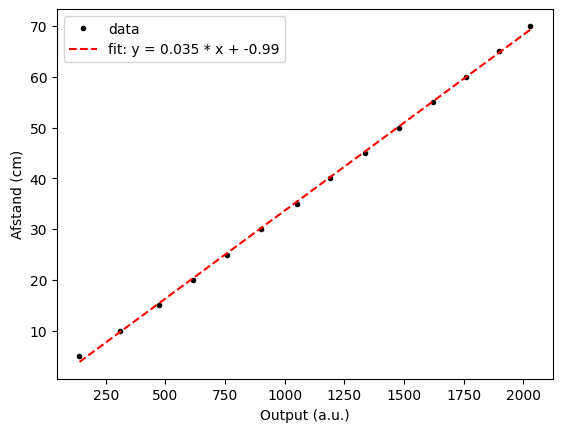

0.034612781102399626
-0.9894125858680405


In [3]:
# verwerk hier jullie kalibratiemetingen

output =  np.array([140, 310, 475, 615, 760, 903, 1050, 1190, 1335, 1480, 1620, 1760, 1900, 2030])
afstand_lineaal = np.array([5, 10, 15, 20, 25, 30, 35 ,40 ,45, 50, 55, 60, 65, 70])

def kalibratie_fit(x,a,b):
    return a*x + b

popt, pcov = curve_fit(kalibratie_fit, output, afstand_lineaal)
rc = popt[0]    
sys_fout = popt[1]

plt.figure()
plt.plot(output, afstand_lineaal, 'k.', label='data',)
plt.plot(output, kalibratie_fit(output, rc, sys_fout),  'r--', label='fit: y = {:.3f} * x + {:.2f}'.format(rc, sys_fout))
plt.xlabel('Output (a.u.)')
plt.ylabel('Afstand (cm)')
plt.legend()
plt.show()

print(rc)
print(sys_fout)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.8
1   0  30   0  20  42.2
2  40   0  30   0  41.5
3  30   0  20   0  41.0


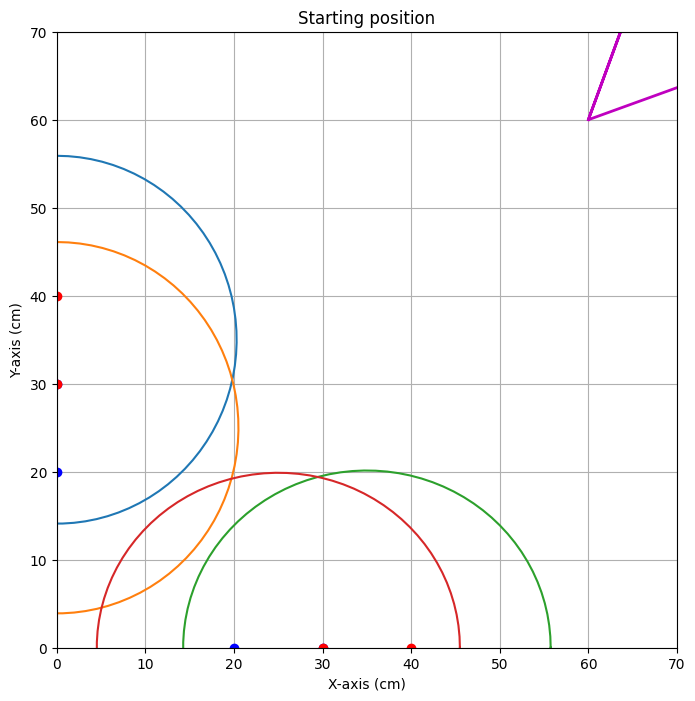


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.330


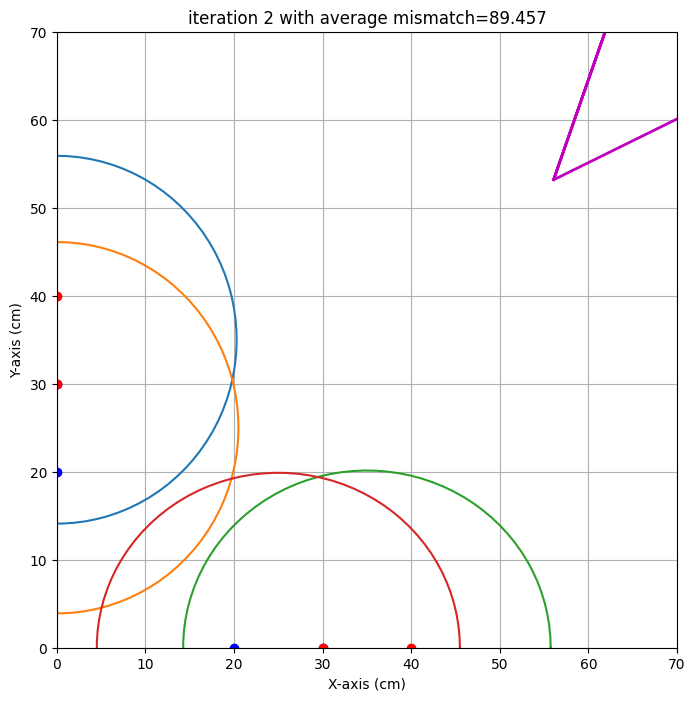

end iteration 2 with average mismatch=89.457


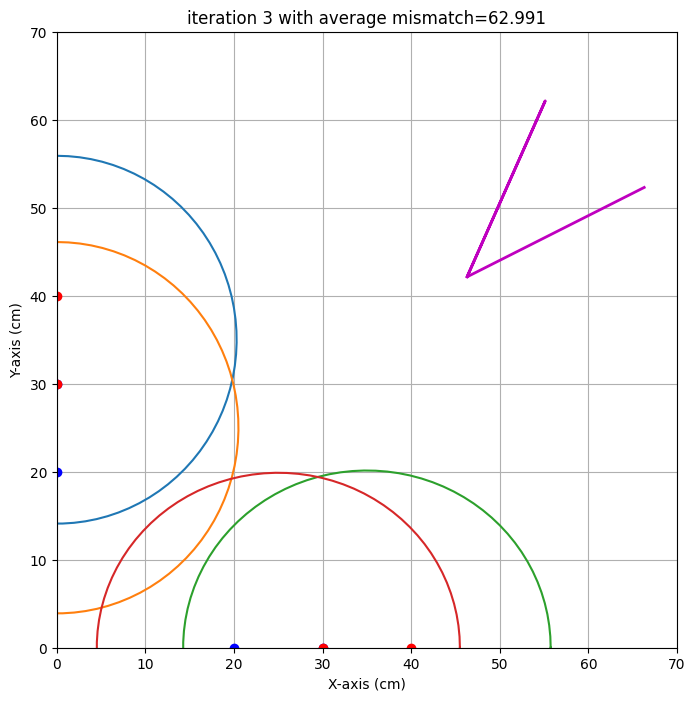

end iteration 3 with average mismatch=62.991


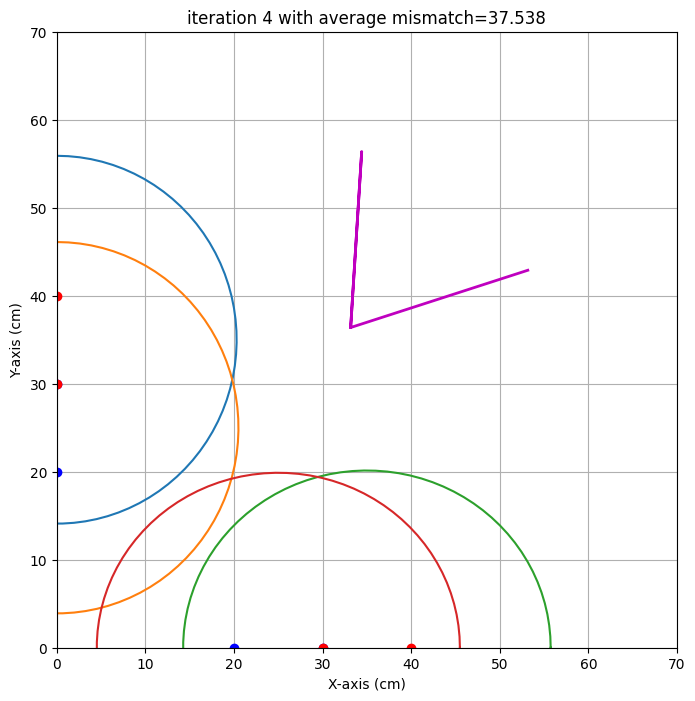

end iteration 4 with average mismatch=37.538


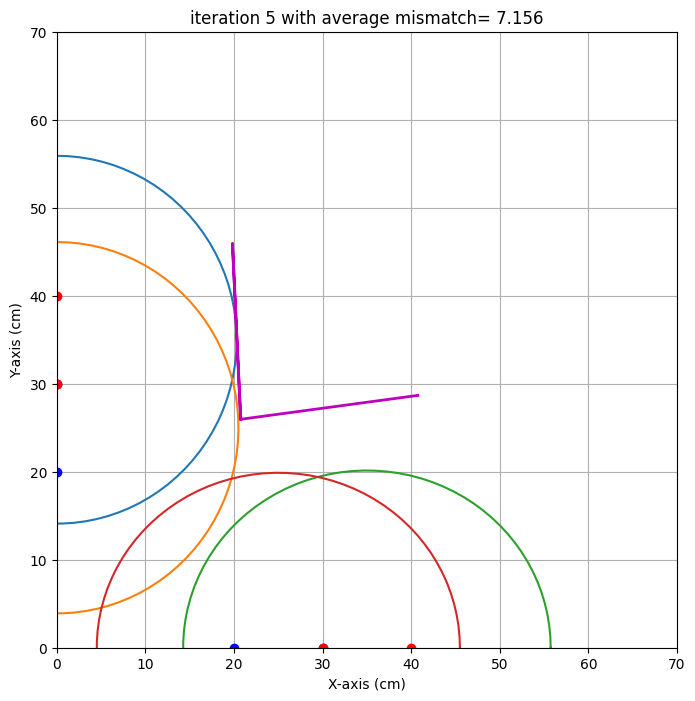

end iteration 5 with average mismatch= 7.156


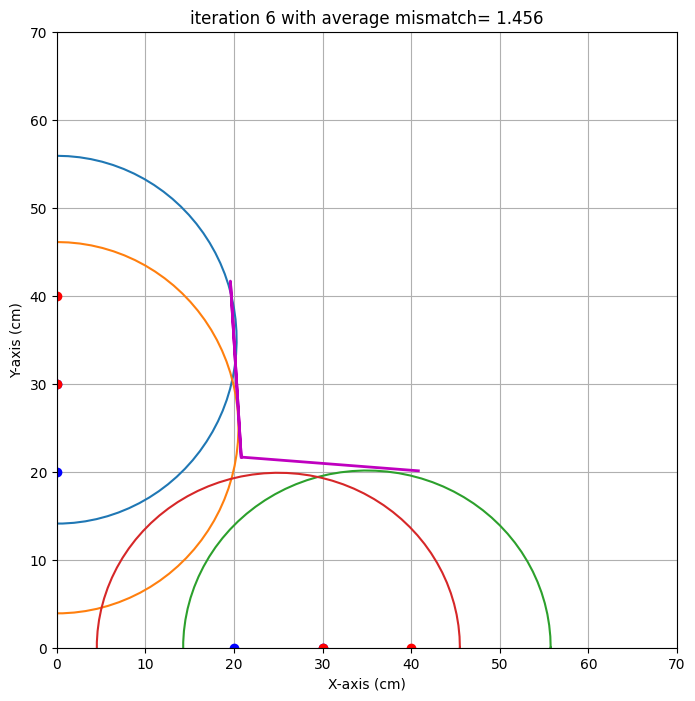

end iteration 6 with average mismatch= 1.456


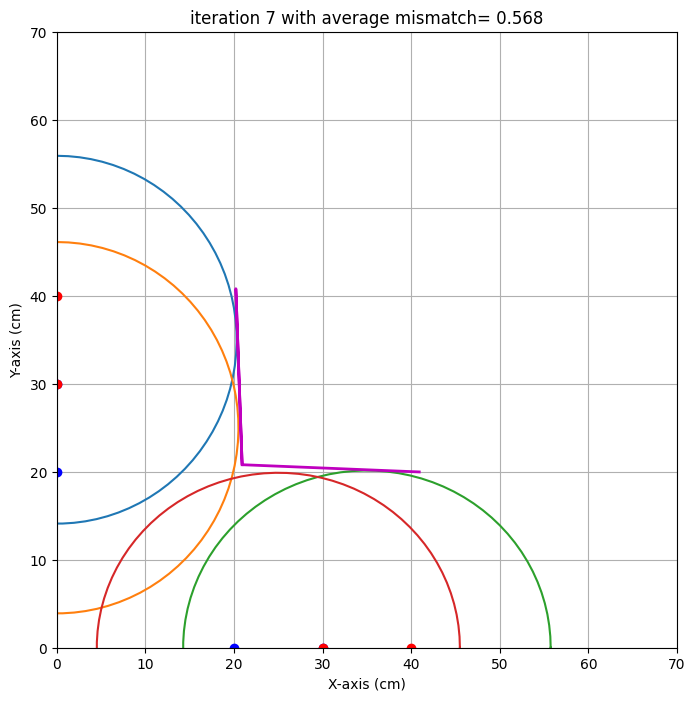

end iteration 7 with average mismatch= 0.568


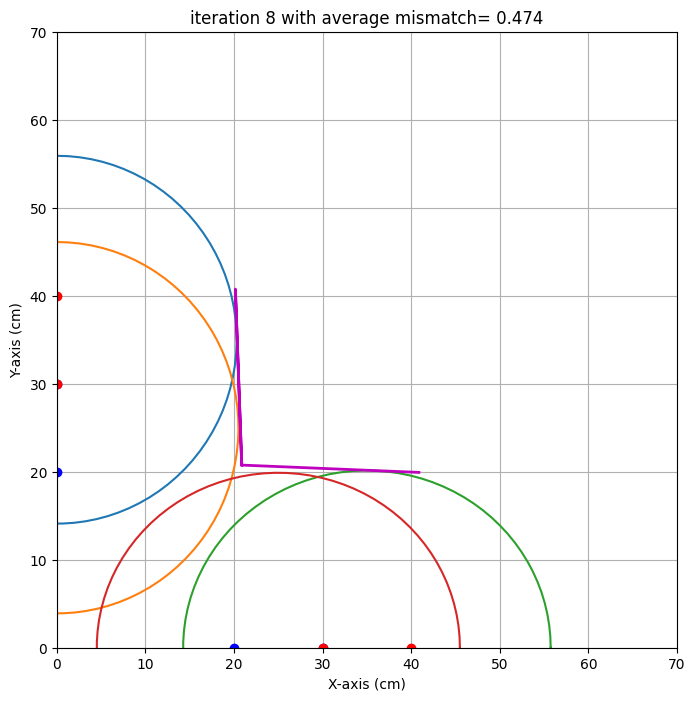

end iteration 8 with average mismatch= 0.474
end iteration 9 with average mismatch= 0.459
end iteration 10 with average mismatch= 0.457
end iteration 11 with average mismatch= 0.457
end iteration 12 with average mismatch= 0.456
end iteration 13 with average mismatch= 0.456
end iteration 14 with average mismatch= 0.456
end iteration 15 with average mismatch= 0.456


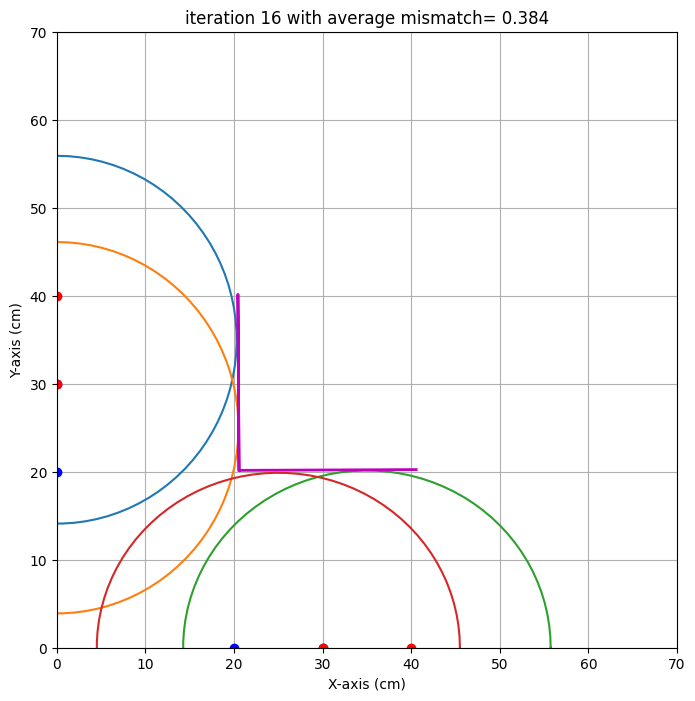

end iteration 16 with average mismatch= 0.384


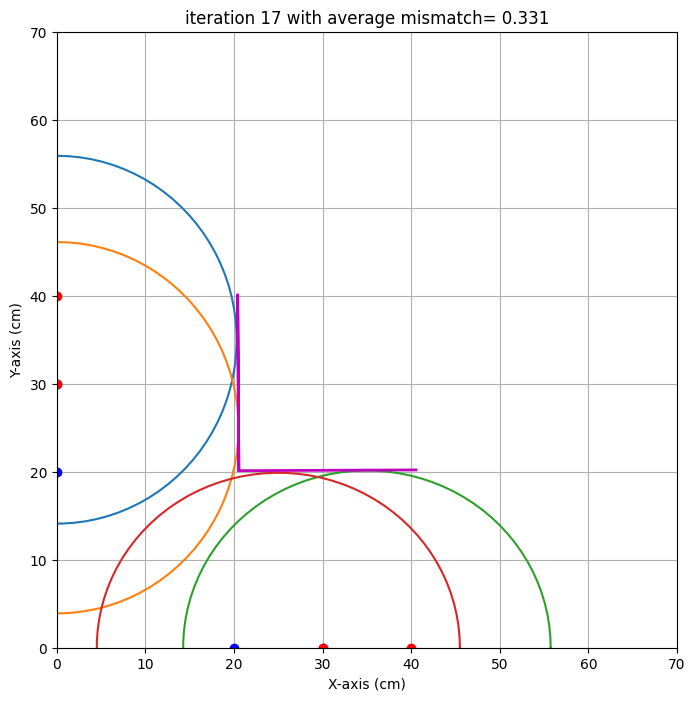

end iteration 17 with average mismatch= 0.331
end iteration 18 with average mismatch= 0.313
end iteration 19 with average mismatch= 0.309
end iteration 20 with average mismatch= 0.293


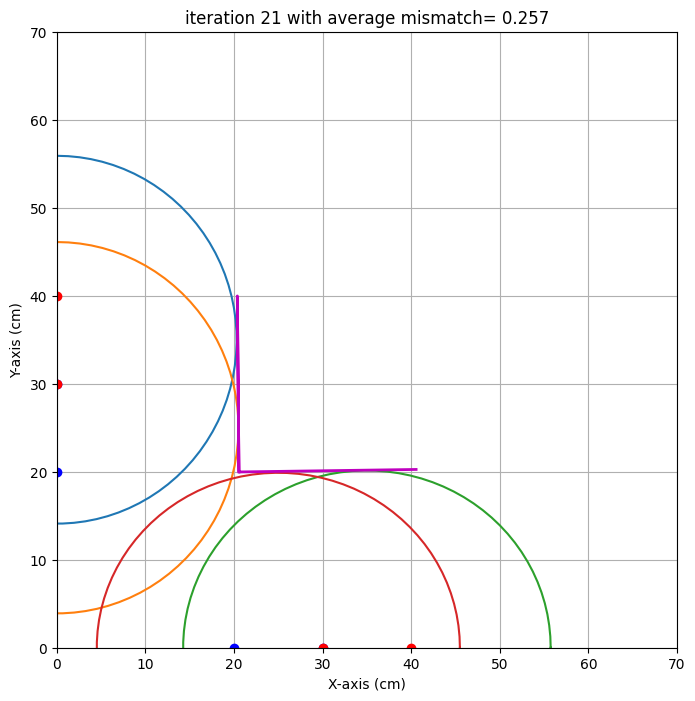

end iteration 21 with average mismatch= 0.257
end iteration 22 with average mismatch= 0.243
end iteration 23 with average mismatch= 0.243
end iteration 24 with average mismatch= 0.243
end iteration 25 with average mismatch= 0.242
end iteration 26 with average mismatch= 0.242
end iteration 27 with average mismatch= 0.242
end iteration 28 with average mismatch= 0.242
end iteration 29 with average mismatch= 0.242
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.242
###############################################################################
end of iteration  30
Best alpha=   0.81 with uncertainty=   1.53
Best beta =  -0.53 with uncertainty=   2.13
Best x0   =  20.54 with uncertainty=   0.68
Best y0   =  19.96 with uncertainty=   0.10
###############################################################################


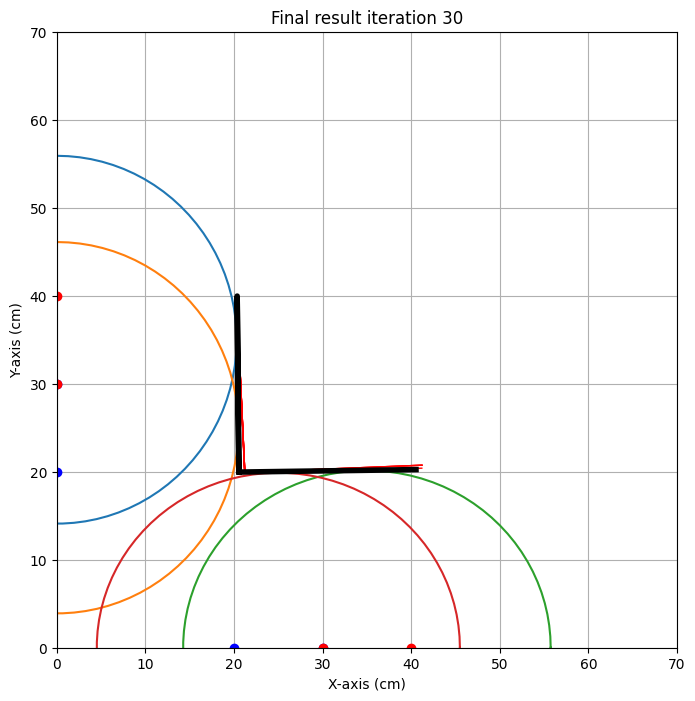

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.8],
    [0,30,0,20,42.2],
    #[0,10,0,20,46.6], ongeldig
    [40,0,30,0,41.5],
    [30,0,20,0,41.0],
    #[10,0,20,0,45.7], ongeldig
    #[10,0,0,10,49.0]   ongeldig
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.5 cm met een standaardafwijking van 0.7 cm 
y0: 20.0 cm met een standaardafwijking van 0.1 cm 
alpha: 0.8 graden met een standaardafwijking van 1.5 graad 
beta: -0.5 graden met een standaardafwijking van 2.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Max]
<img src="foto_1.jpeg" width="400">

#### algoritme [Luuc]
<img src="foto_2.jpeg" width="400">

#### algoritme [Robert]
<img src="foto_3.jpeg" width="400">

In [6]:
meting = 47.7
afstand_tussen_sensoren = 10

m = np.sqrt((meting/2)**2 - (afstand_tussen_sensoren/2)**2)
print(m)

23.320002144082235


## Opdracht 6: Test iteratie 0.

Bij de eerste test iteratie 0 hebben we een te scherpe hoek alfa gebruikt. Daarom hebben we later voor een minder scherpe hoek gekozen. De TA zei dat we maar 1 algoritme opnieuw hoefden te testen, wegens de tijd.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':38,  #zelf aanvullen,
           'y0':21.5,  #zelf aanvullen,
           'alpha':15, #zelf aanvullen,
           'beta':10,}  #zelf aanvullen
          
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Luuc' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [0,30,0,20, ongeldig]  
    [0,60,0,70,87],
    [0,45,0,55,86.8],
    #[30,0,20,0, ongeldig],
    [60,0,70,0,91.7],
    [55,0,45,0,82]
    ]),
       'Max' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[ #met te scherpe hoek
    #[30,0,40,0, ongeldig]  
    [50,0,60,0,86.7],
    [0,50,0,60,87.2],
    [55,0,65,0, 89],
    [0,55,0,65,87.5]
    ]),
       'Robert' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [30,0,40,0, ongeldig]  
    [50,0,60,0,50.5],
    [0,41,0,31,81.2],
    [55,0,45,0,47.7],
    [0,26,0,36,79.5]
    ])
      }

## Opdracht 7: Evaluatie.

Luuc
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  60   0  70  87.0
1   0  45   0  55  86.8
2  60   0  70   0  91.7
3  55   0  45   0  82.0


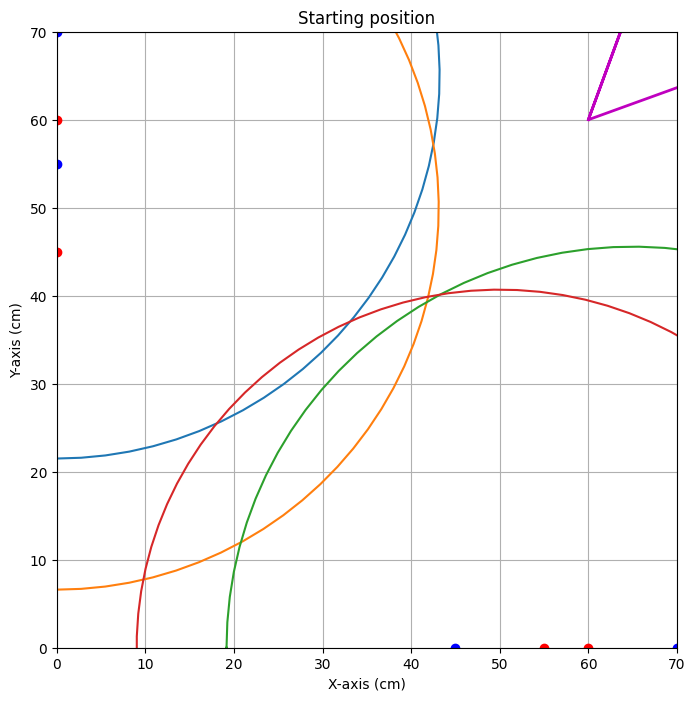


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.060


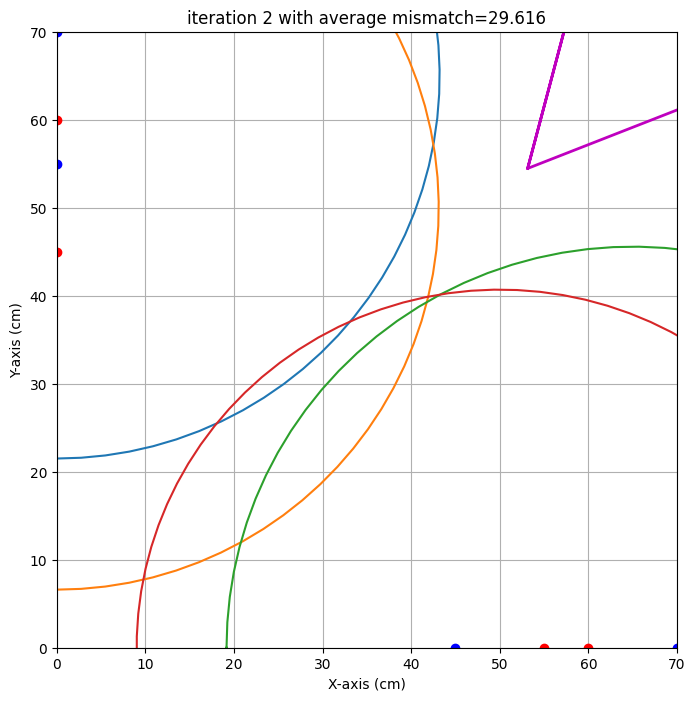

end iteration 2 with average mismatch=29.616


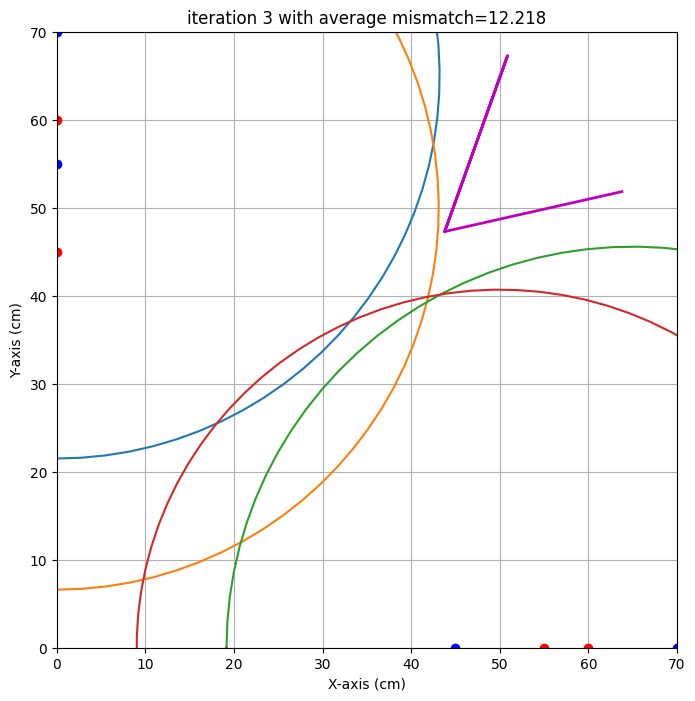

end iteration 3 with average mismatch=12.218


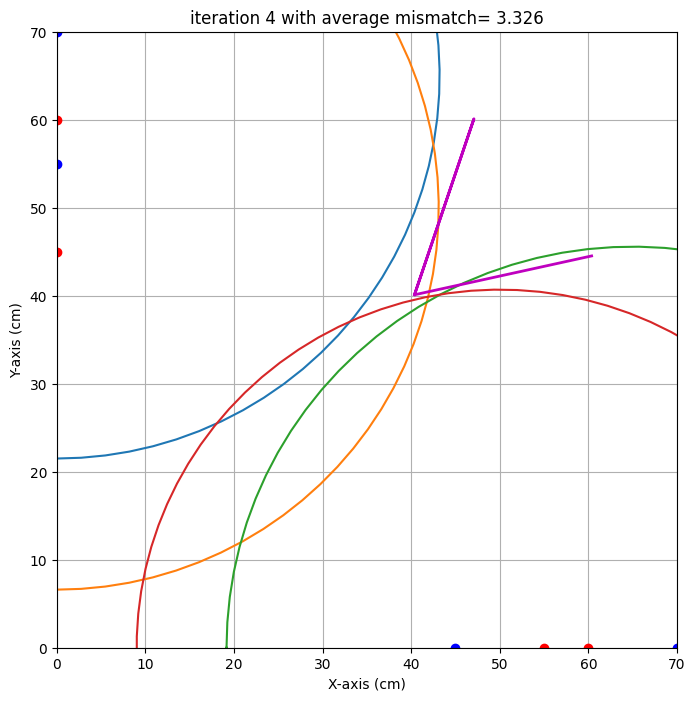

end iteration 4 with average mismatch= 3.326


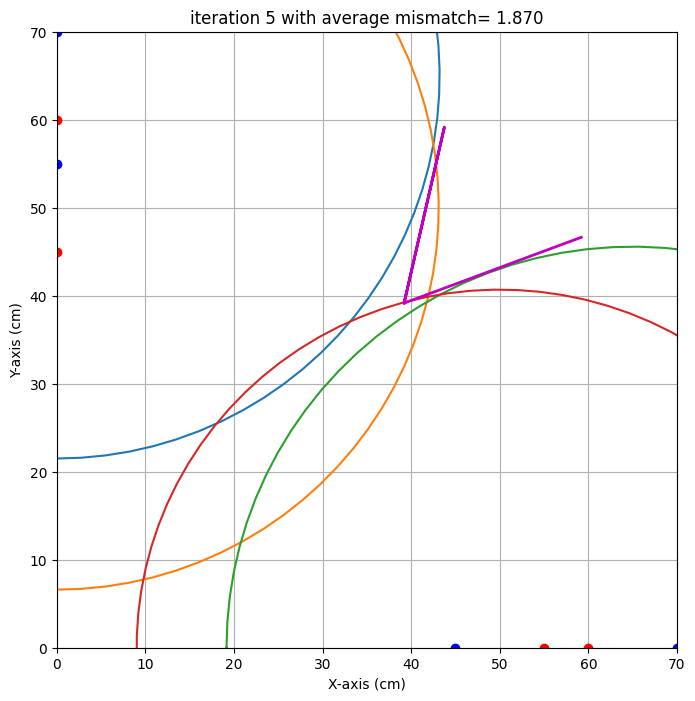

end iteration 5 with average mismatch= 1.870


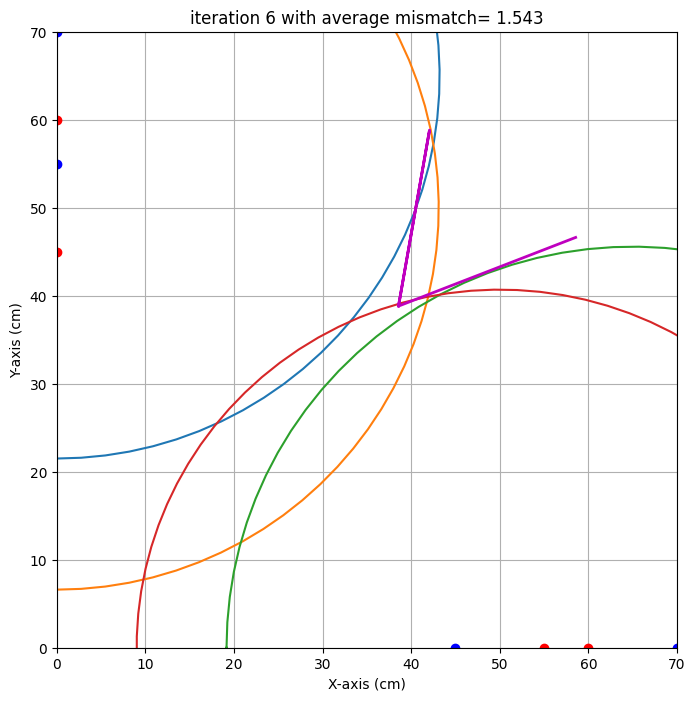

end iteration 6 with average mismatch= 1.543
end iteration 7 with average mismatch= 1.419
end iteration 8 with average mismatch= 1.398
end iteration 9 with average mismatch= 1.397
end iteration 10 with average mismatch= 1.334
end iteration 11 with average mismatch= 1.334
end iteration 12 with average mismatch= 1.334
end iteration 13 with average mismatch= 1.334
end iteration 14 with average mismatch= 1.334
end iteration 15 with average mismatch= 1.334
end iteration 16 with average mismatch= 1.334
end iteration 17 with average mismatch= 1.334
end iteration 18 with average mismatch= 1.334
end iteration 19 with average mismatch= 1.334
end iteration 20 with average mismatch= 1.283
end iteration 21 with average mismatch= 1.283
end iteration 22 with average mismatch= 1.283
end iteration 23 with average mismatch= 1.283
end iteration 24 with average mismatch= 1.283
end iteration 25 with average mismatch= 1.283
end iteration 26 with average mismatch= 1.283
end iteration 27 with average mismatch

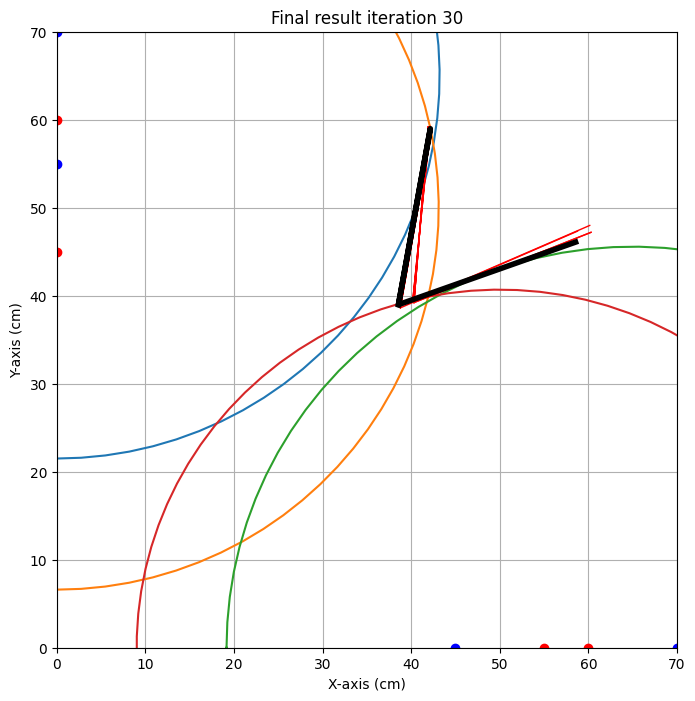

{'alpha': np.float64(19.571669397779637), 'alpha_eps': np.float64(3.9912370550439498), 'beta': np.float64(10.204285021146312), 'beta_eps': np.float64(5.581888465722421), 'x0': np.float64(38.56046080568188), 'x0_eps': np.float64(1.7454068483377654), 'y0': np.float64(38.98284040187595), 'y0_eps': np.float64(0.36400263638290653)}
Max
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  86.7
1   0  50   0  60  87.2
2  55   0  65   0  89.0
3   0  55   0  65  87.5


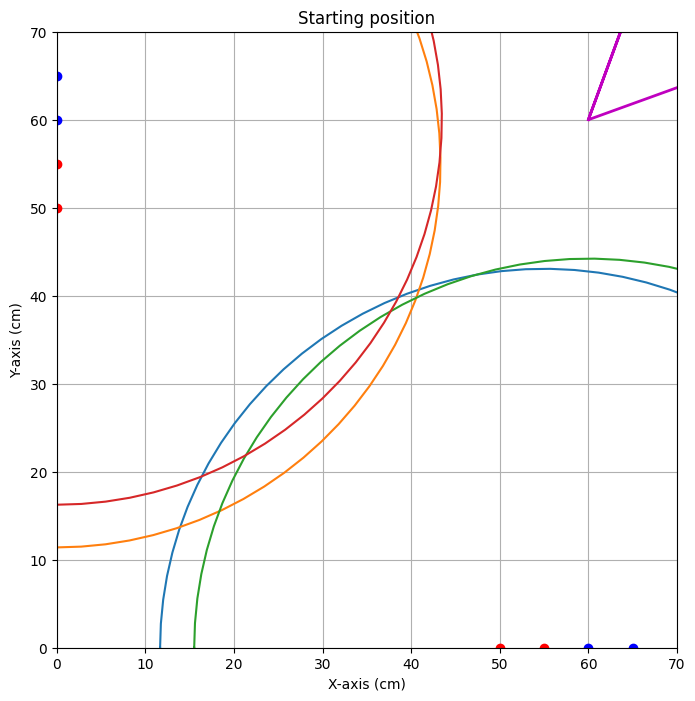


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.555


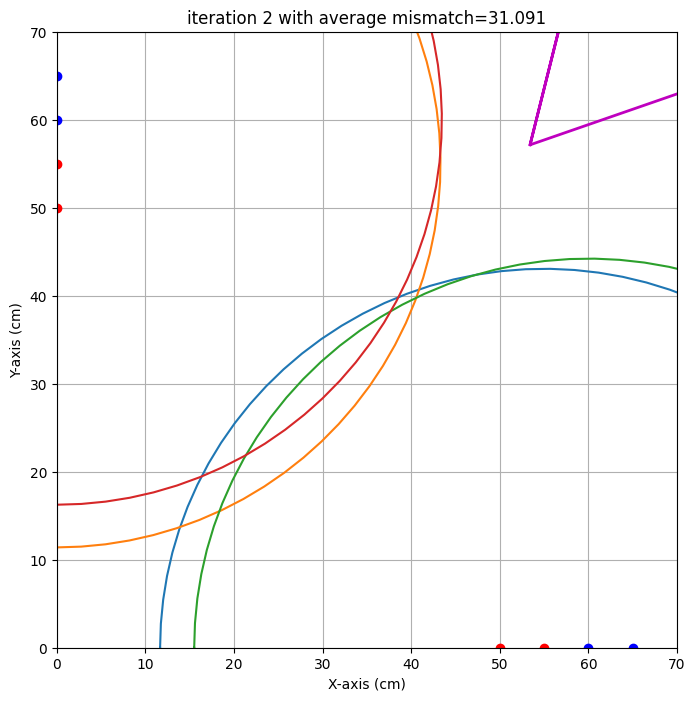

end iteration 2 with average mismatch=31.091


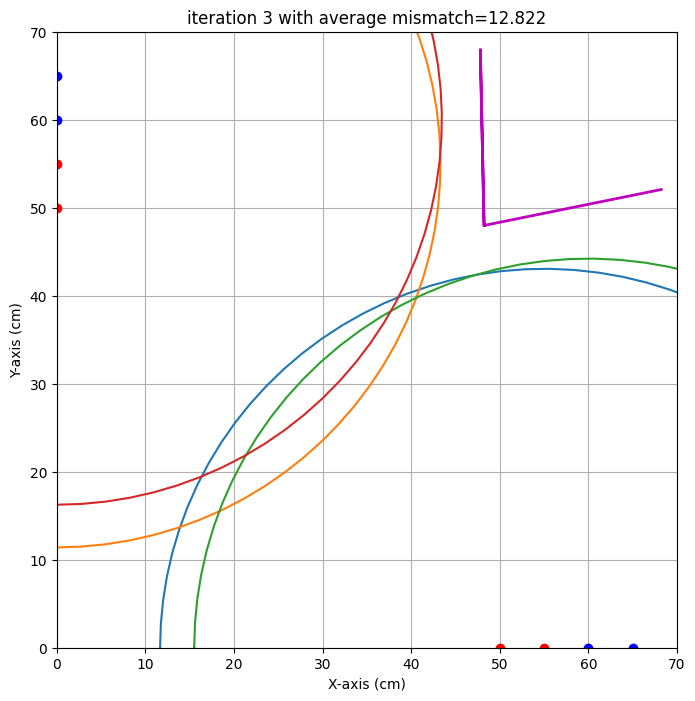

end iteration 3 with average mismatch=12.822


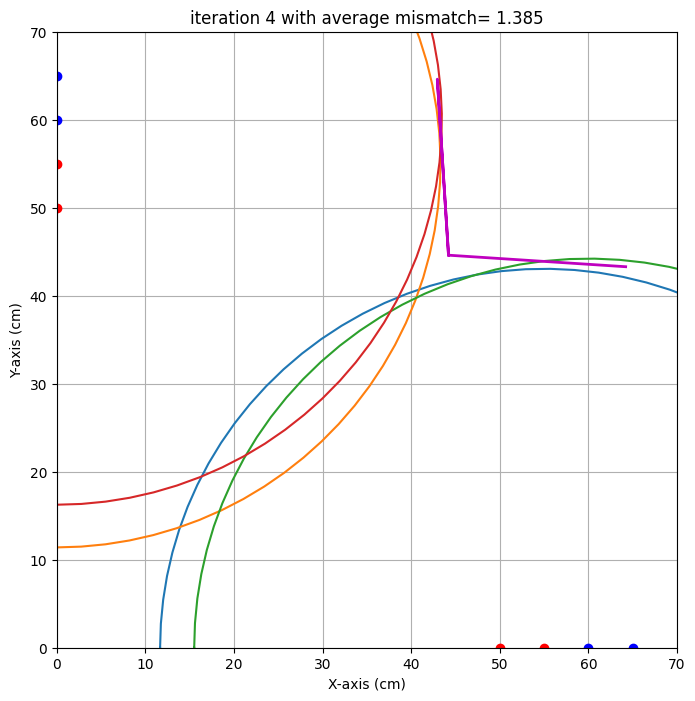

end iteration 4 with average mismatch= 1.385


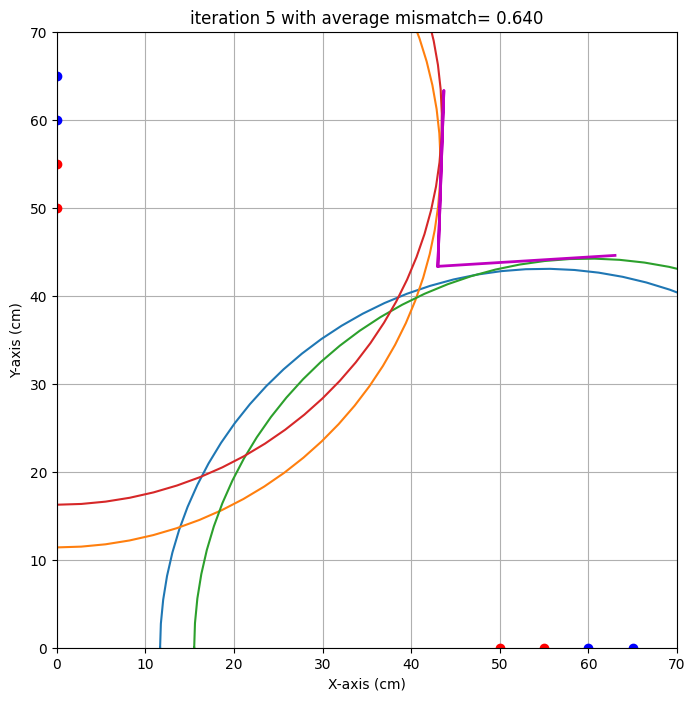

end iteration 5 with average mismatch= 0.640


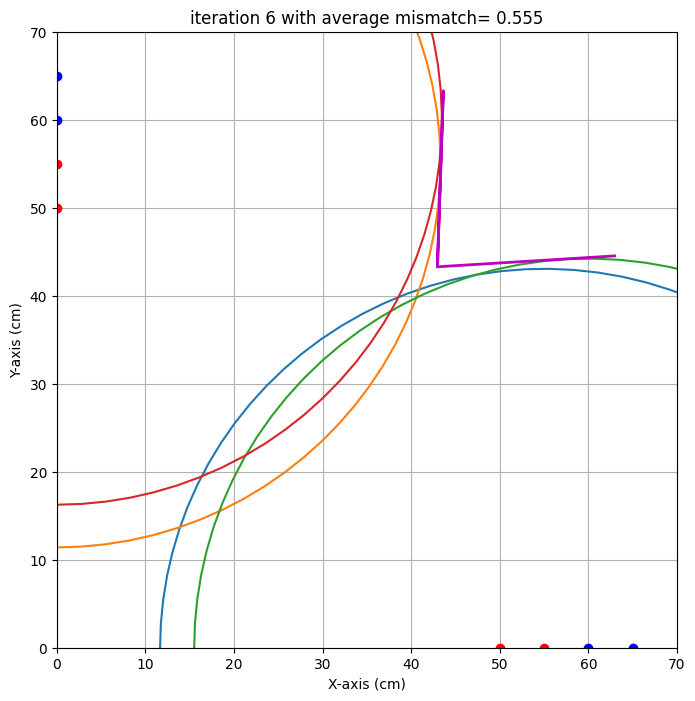

end iteration 6 with average mismatch= 0.555
end iteration 7 with average mismatch= 0.549
end iteration 8 with average mismatch= 0.547
end iteration 9 with average mismatch= 0.542
end iteration 10 with average mismatch= 0.537


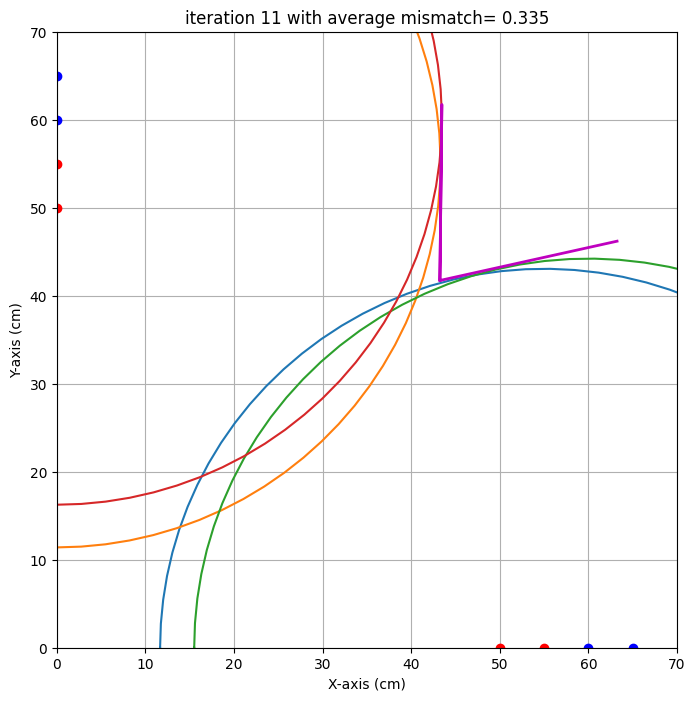

end iteration 11 with average mismatch= 0.335


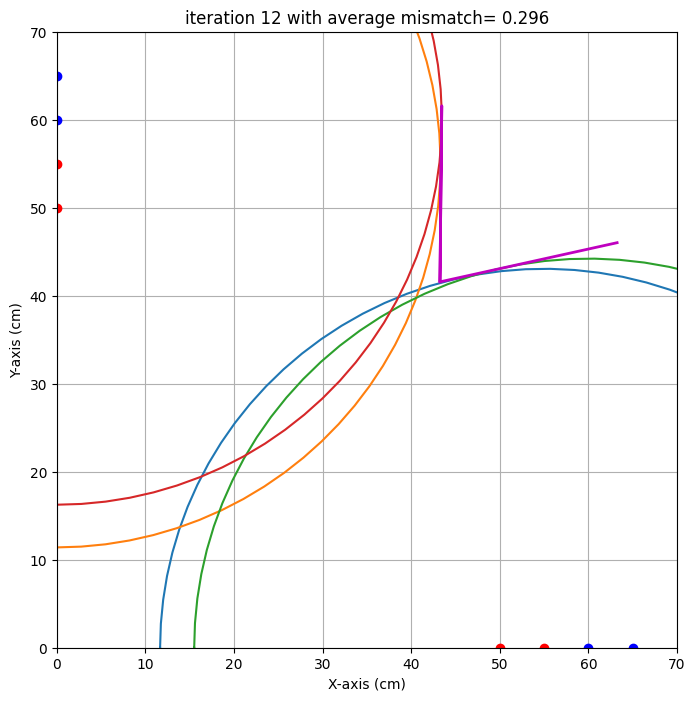

end iteration 12 with average mismatch= 0.296


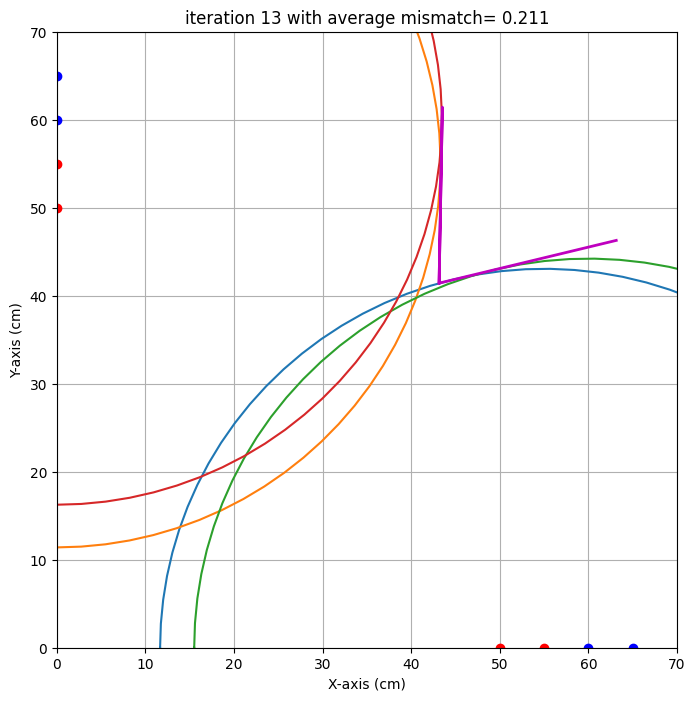

end iteration 13 with average mismatch= 0.211
end iteration 14 with average mismatch= 0.207
end iteration 15 with average mismatch= 0.206
end iteration 16 with average mismatch= 0.206
end iteration 17 with average mismatch= 0.206
end iteration 18 with average mismatch= 0.206
end iteration 19 with average mismatch= 0.206
end iteration 20 with average mismatch= 0.206
end iteration 21 with average mismatch= 0.206
end iteration 22 with average mismatch= 0.206
end iteration 23 with average mismatch= 0.206
end iteration 24 with average mismatch= 0.206
end iteration 25 with average mismatch= 0.200


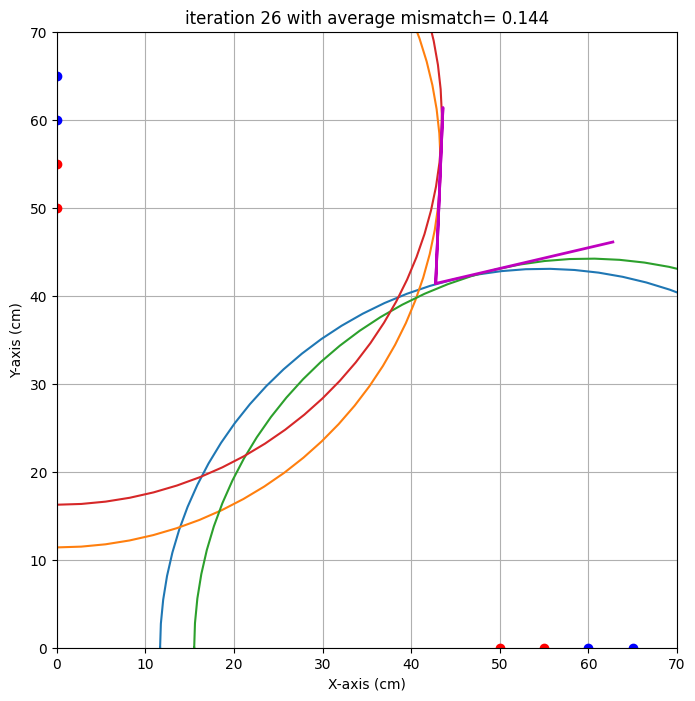

end iteration 26 with average mismatch= 0.144
end iteration 27 with average mismatch= 0.143
end iteration 28 with average mismatch= 0.142
end iteration 29 with average mismatch= 0.142
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.142
###############################################################################
end of iteration  30
Best alpha=  13.26 with uncertainty=   5.28
Best beta =   2.34 with uncertainty=   6.12
Best x0   =  42.77 with uncertainty=   1.01
Best y0   =  41.39 with uncertainty=   0.38
###############################################################################


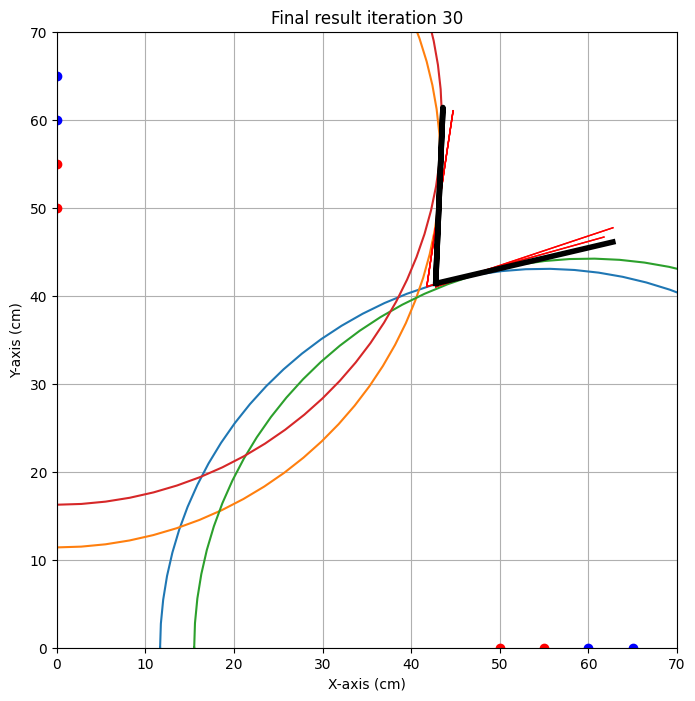

{'alpha': np.float64(13.258310803681708), 'alpha_eps': np.float64(5.283624450289112), 'beta': np.float64(2.3423084848640316), 'beta_eps': np.float64(6.116710068943907), 'x0': np.float64(42.76550280534078), 'x0_eps': np.float64(1.0050789632005817), 'y0': np.float64(41.38973964724449), 'y0_eps': np.float64(0.3771208251960374)}
Robert
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  50.5
1   0  41   0  31  81.2
2  55   0  45   0  47.7
3   0  26   0  36  79.5


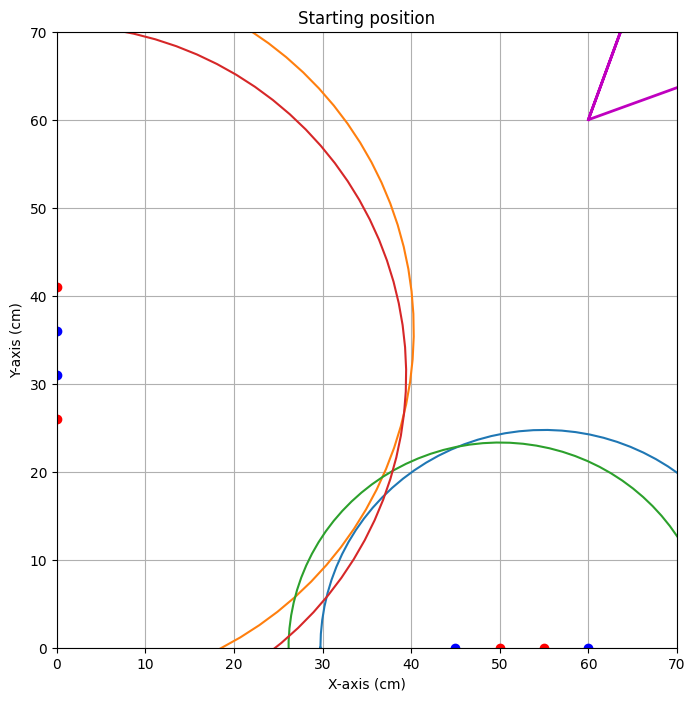


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.919


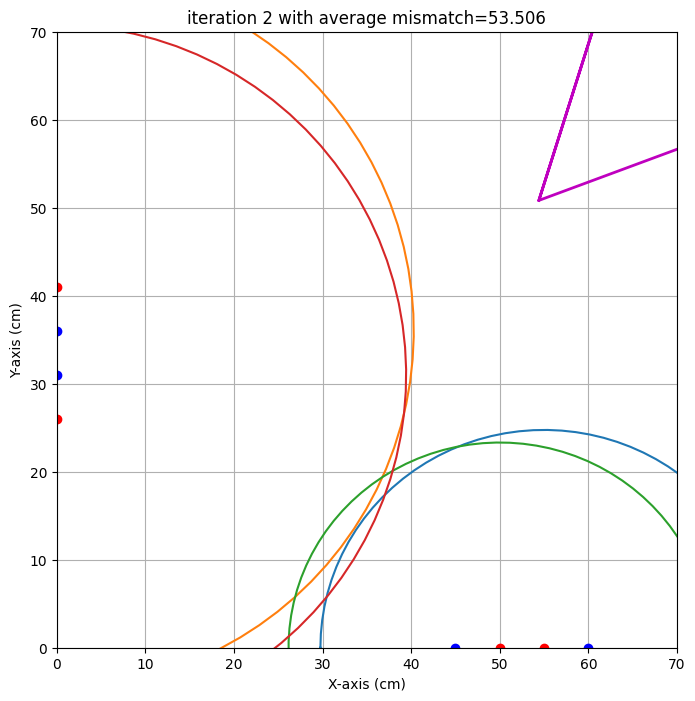

end iteration 2 with average mismatch=53.506


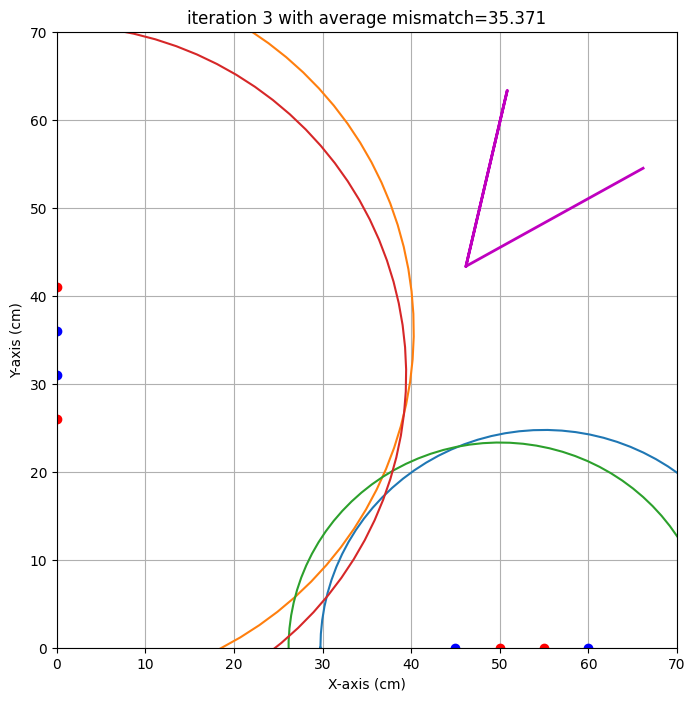

end iteration 3 with average mismatch=35.371


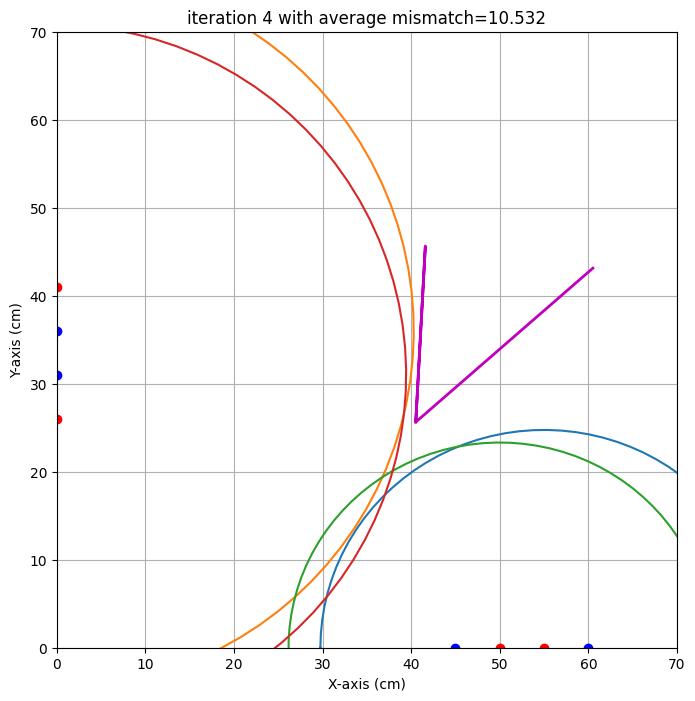

end iteration 4 with average mismatch=10.532


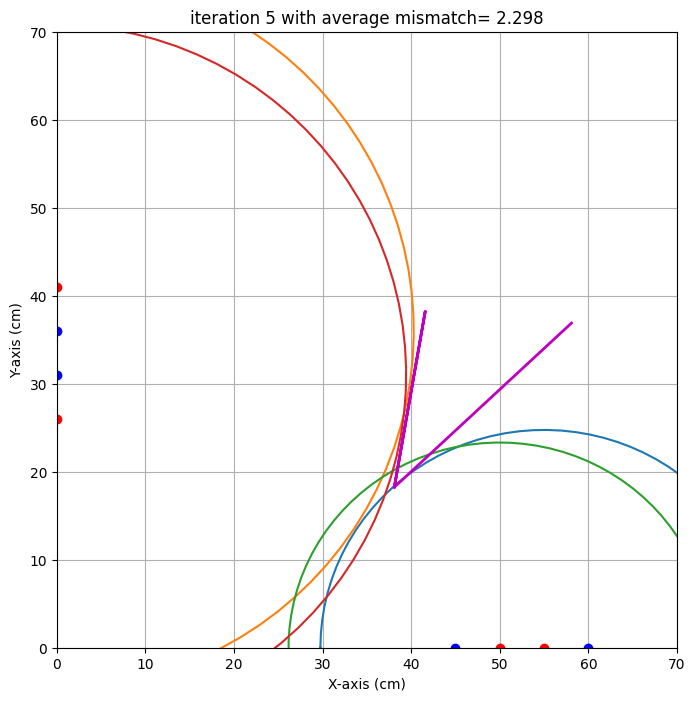

end iteration 5 with average mismatch= 2.298


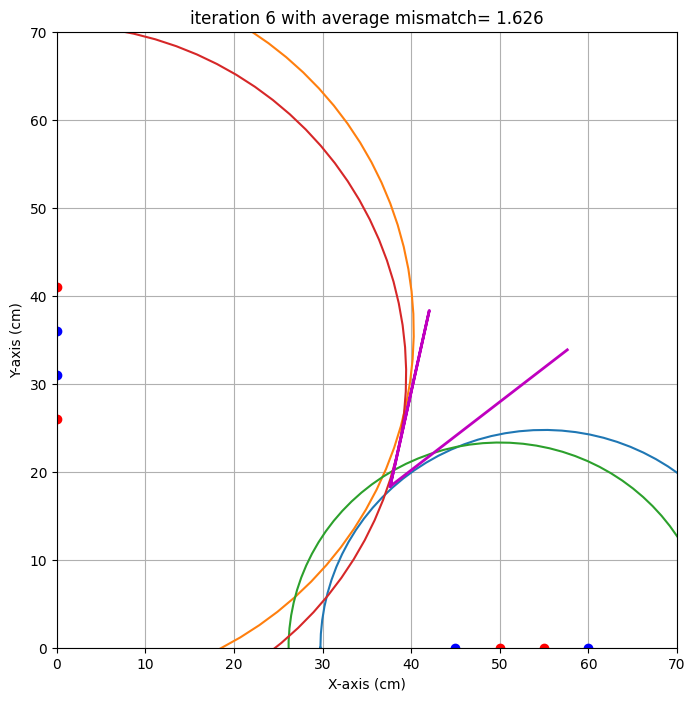

end iteration 6 with average mismatch= 1.626
end iteration 7 with average mismatch= 1.569
end iteration 8 with average mismatch= 1.489
end iteration 9 with average mismatch= 1.470
end iteration 10 with average mismatch= 1.470


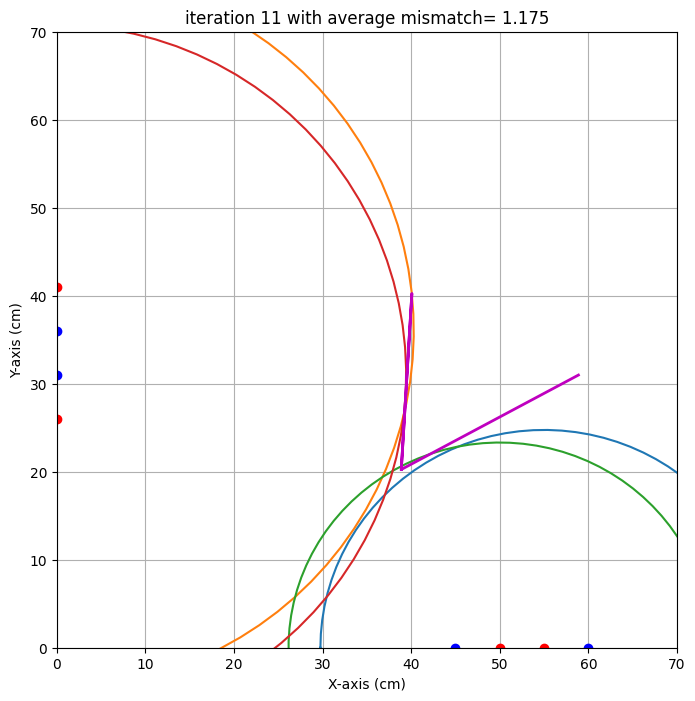

end iteration 11 with average mismatch= 1.175


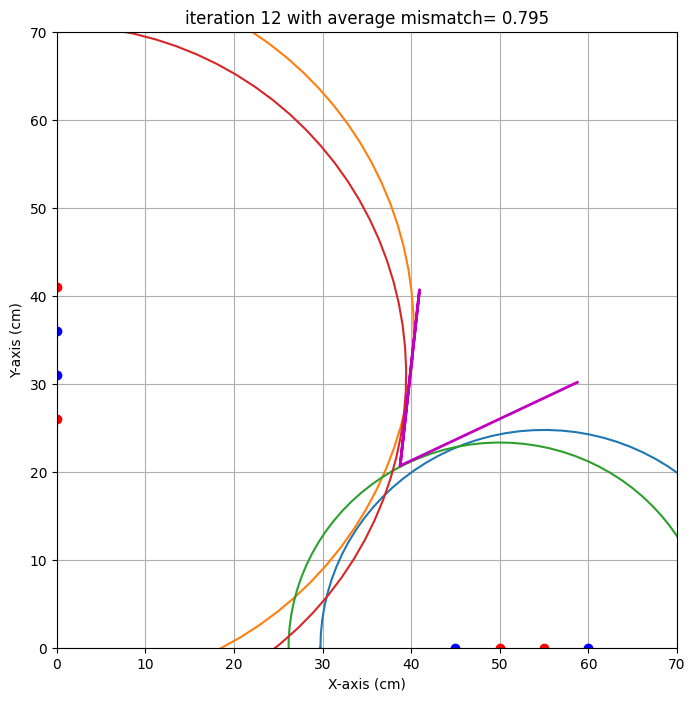

end iteration 12 with average mismatch= 0.795


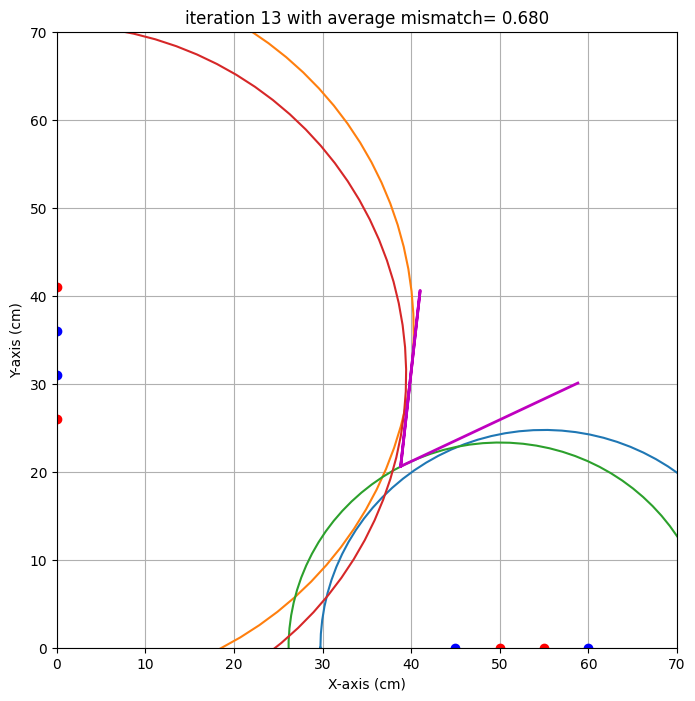

end iteration 13 with average mismatch= 0.680
end iteration 14 with average mismatch= 0.634


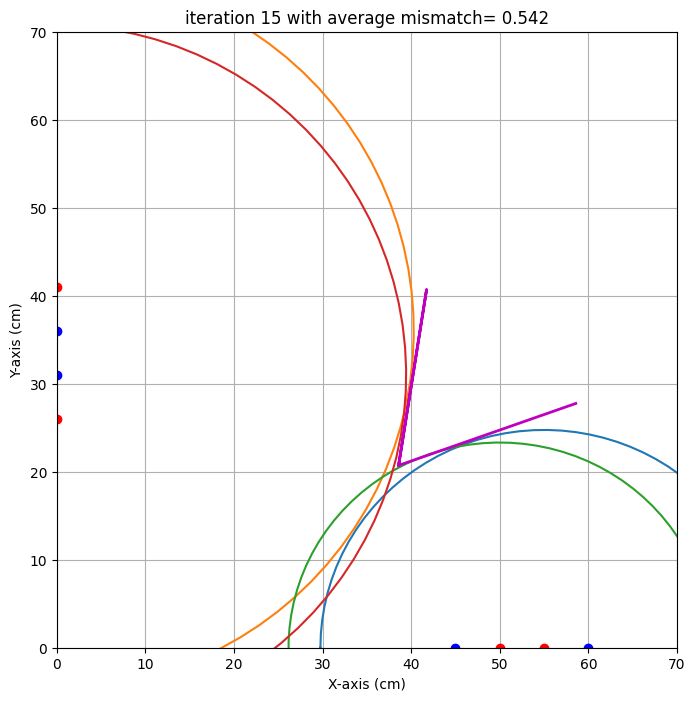

end iteration 15 with average mismatch= 0.542


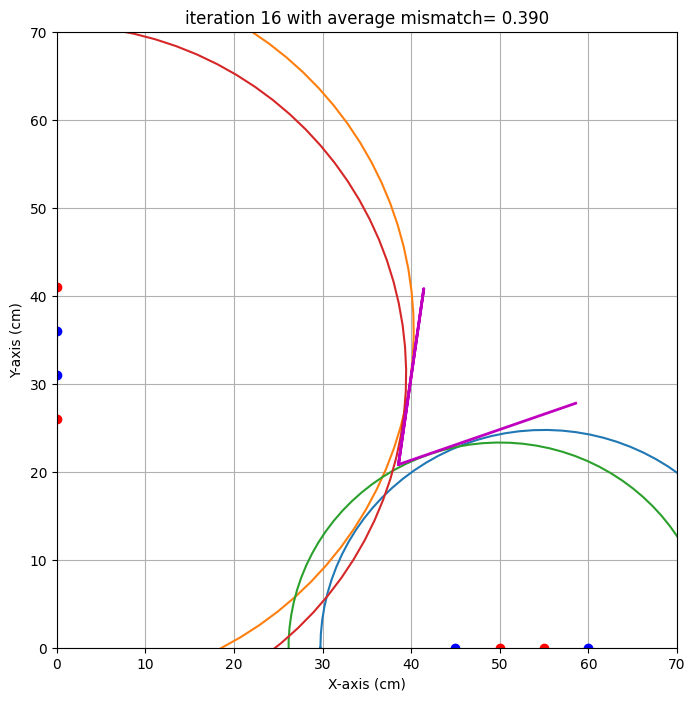

end iteration 16 with average mismatch= 0.390


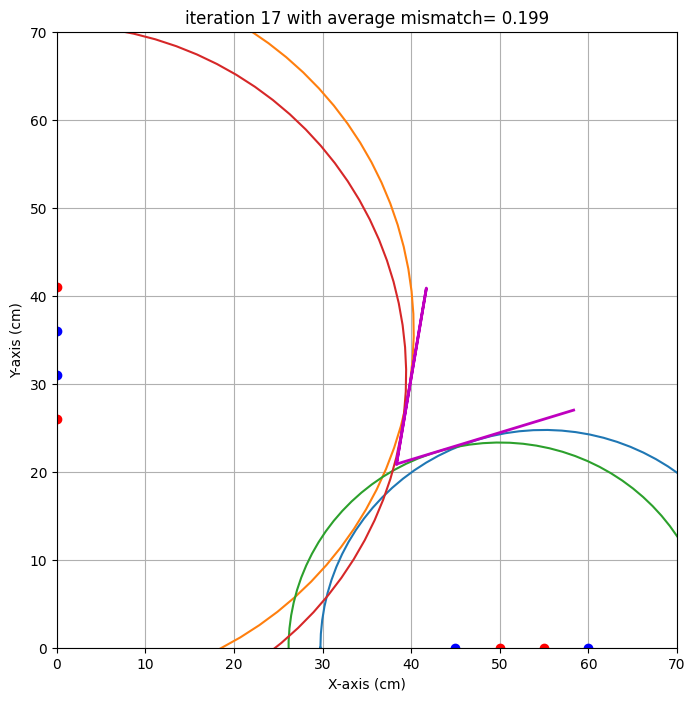

end iteration 17 with average mismatch= 0.199


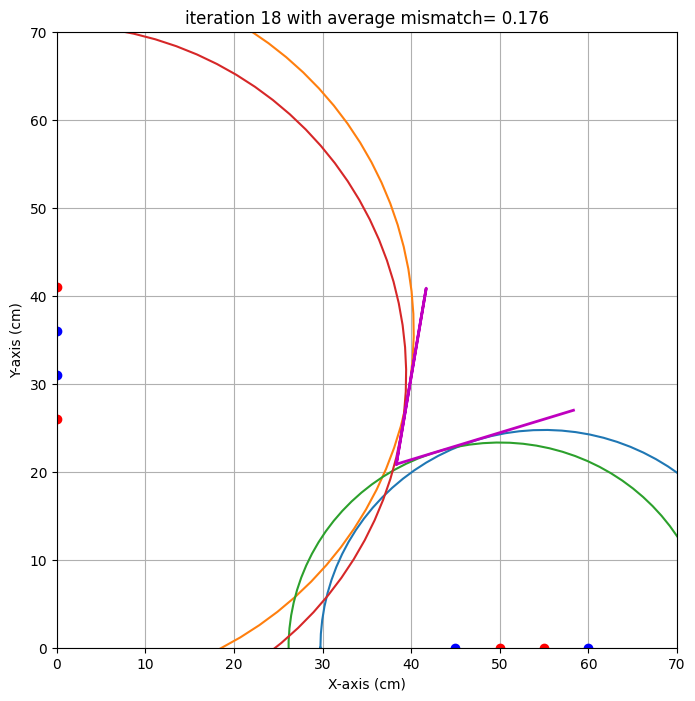

end iteration 18 with average mismatch= 0.176
end iteration 19 with average mismatch= 0.171
end iteration 20 with average mismatch= 0.169
end iteration 21 with average mismatch= 0.169
end iteration 22 with average mismatch= 0.169
end iteration 23 with average mismatch= 0.168


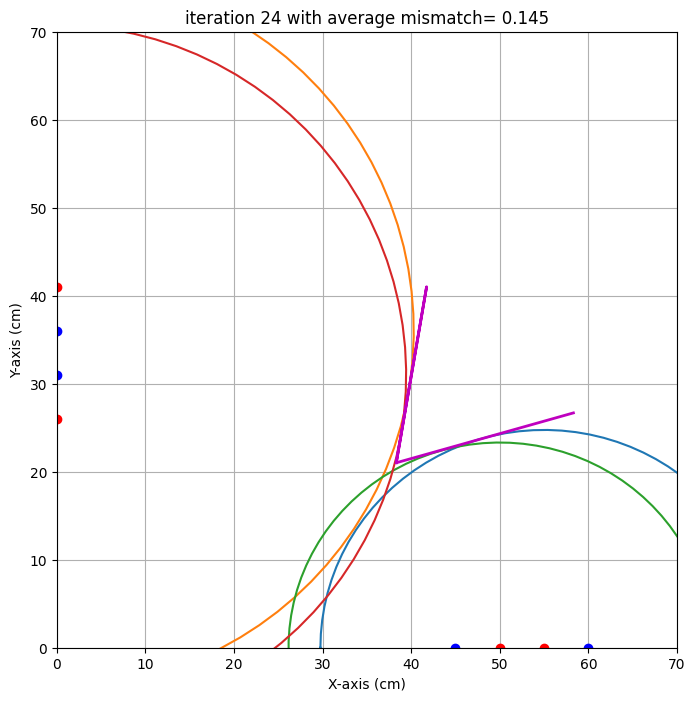

end iteration 24 with average mismatch= 0.145
end iteration 25 with average mismatch= 0.145
end iteration 26 with average mismatch= 0.145
end iteration 27 with average mismatch= 0.145
end iteration 28 with average mismatch= 0.145
end iteration 29 with average mismatch= 0.145
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.145
###############################################################################
end of iteration  30
Best alpha=  15.82 with uncertainty=   1.95
Best beta =   9.72 with uncertainty=   3.09
Best x0   =  38.32 with uncertainty=   0.58
Best y0   =  21.02 with uncertainty=   0.21
###############################################################################


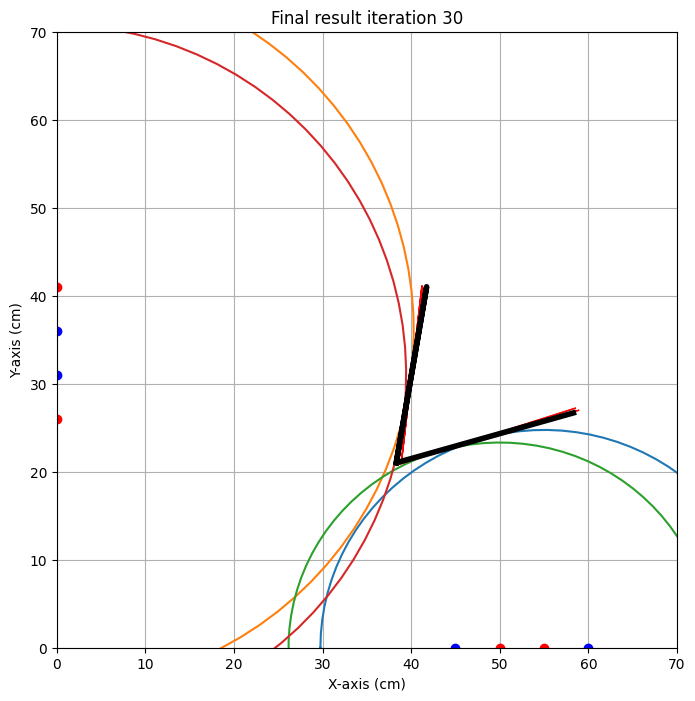

{'alpha': np.float64(15.819520657635644), 'alpha_eps': np.float64(1.954728669178122), 'beta': np.float64(9.718927078790513), 'beta_eps': np.float64(3.089352979372487), 'x0': np.float64(38.31531909975536), 'x0_eps': np.float64(0.580237030678525), 'y0': np.float64(21.01721910102768), 'y0_eps': np.float64(0.21085742417239928)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Luuc 
x0 target is : 38.0. Gevonden waarde: 38.6 cm met een standaardafwijking van 1.7 cm 
y0 target is : 21.5. Gevonden waarde: 39.0 cm met een standaardafwijking van 0.4 cm 
alpha target is : 15.0. Gevonden waarde: 19.6 graden met een standaardafwijking van 4.0 graad 
beta target is : 10.0. Gevonden waarde: 10.2 graden met een standaardafwijking van 5.6 graad 

Max 
x0 target is : 38.0. Gevonden waarde: 42.8 cm met een standaardafwijking van 1.0 cm 
y0 target is : 21.5. Gevonden waarde: 41.4 cm met een standaardafwijking van 0.4 cm 
alpha target is : 15.0. Gevonden waarde: 13.3 graden met een standaardafwijking van 5.3 graad 
beta target is : 10.0. Gevonden waarde: 2.3 graden met een standaardafwijking van 6.1 graad 

Robert 
x0 target is : 38.0. Gevonden waarde: 38.3 cm met een standaardafwijking van 0.6 cm 
y0 target is : 21.5. Gevonden waarde: 21.0 cm met een standaardafwijking van 0.2 cm 
alpha target is : 15.0. Gevonden waarde: 15.8 graden met een standaardafwijking van 2.0 graa

## Opdracht 8: Iteratie1+. 16:00
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [10]:
meting = 70.8
afstand_tussen_sensoren = 10

m = np.sqrt((meting/2)**2 - (afstand_tussen_sensoren/2)**2)
print(m)

35.045113782095214


## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  50.5
1   0  41   0  31  81.2
2  55   0  45   0  47.7
3   0  26   0  36  79.5


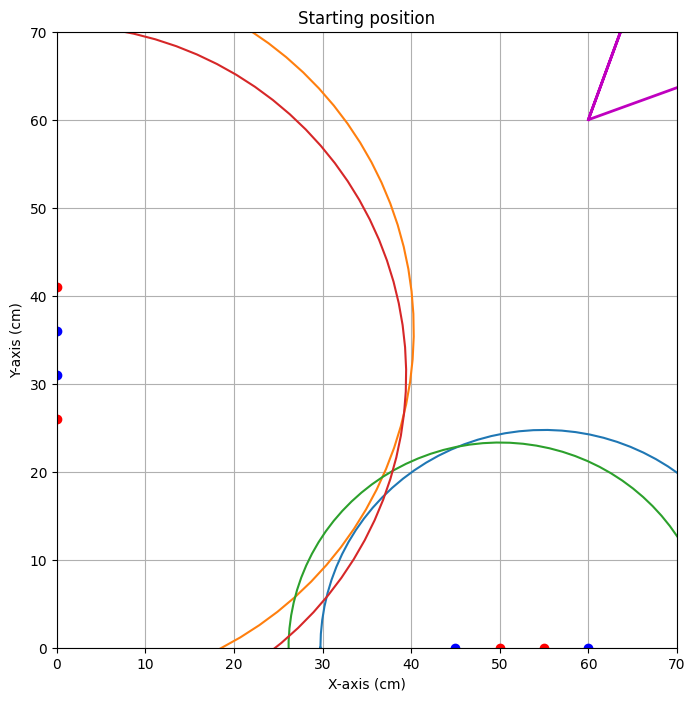


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.919


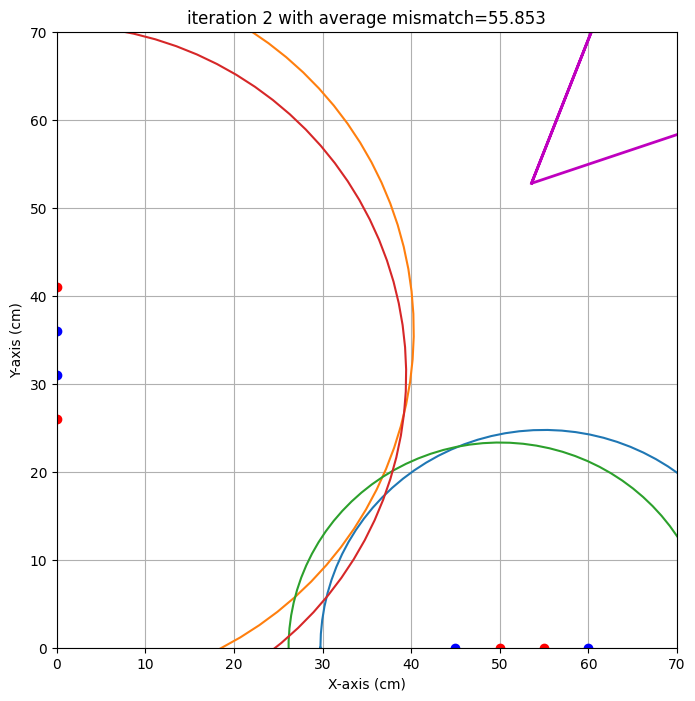

end iteration 2 with average mismatch=55.853


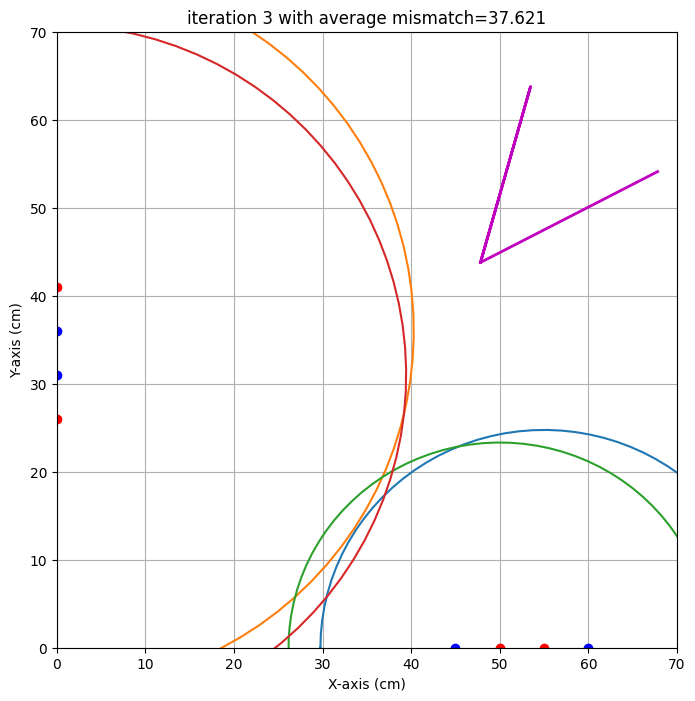

end iteration 3 with average mismatch=37.621


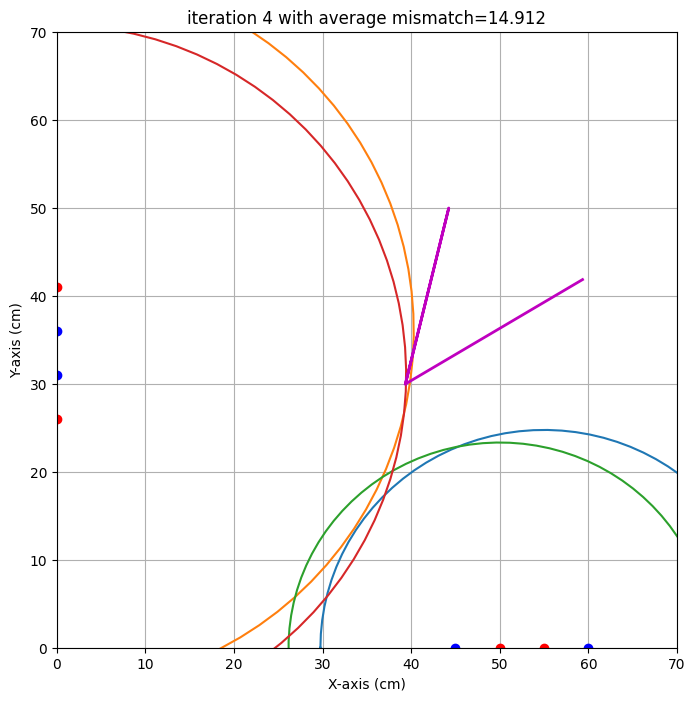

end iteration 4 with average mismatch=14.912


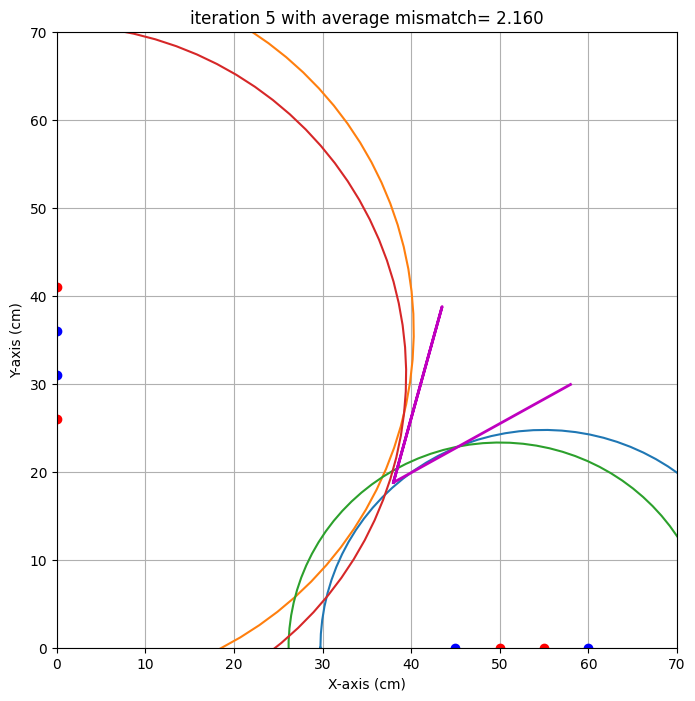

end iteration 5 with average mismatch= 2.160


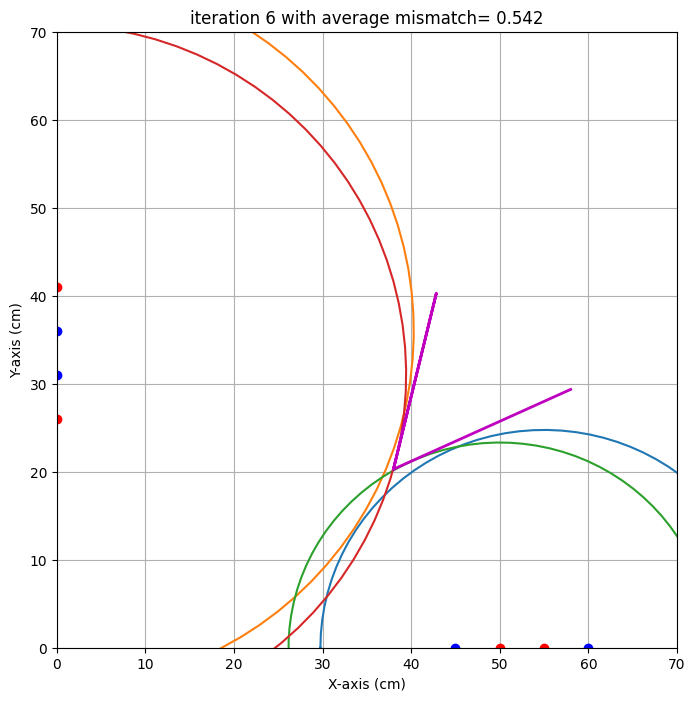

end iteration 6 with average mismatch= 0.542
end iteration 7 with average mismatch= 0.534
end iteration 8 with average mismatch= 0.533
end iteration 9 with average mismatch= 0.518


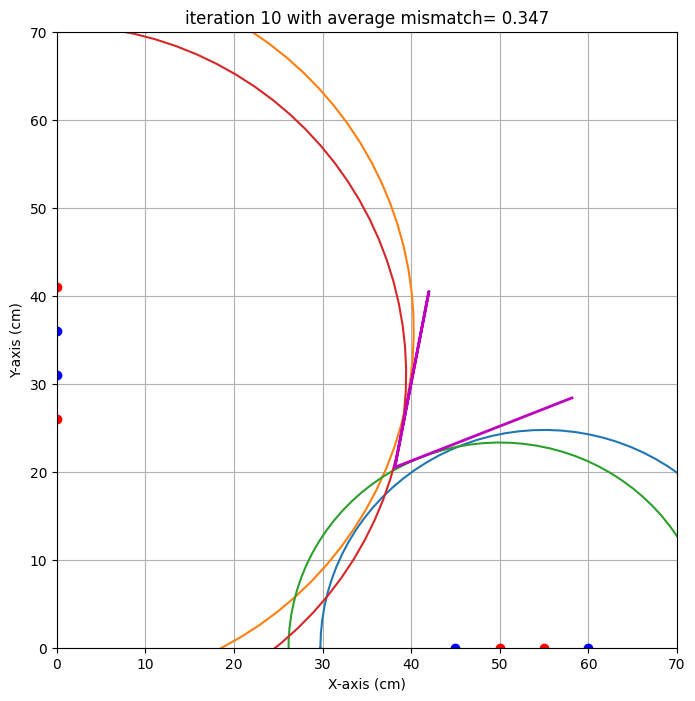

end iteration 10 with average mismatch= 0.347
end iteration 11 with average mismatch= 0.340
end iteration 12 with average mismatch= 0.312


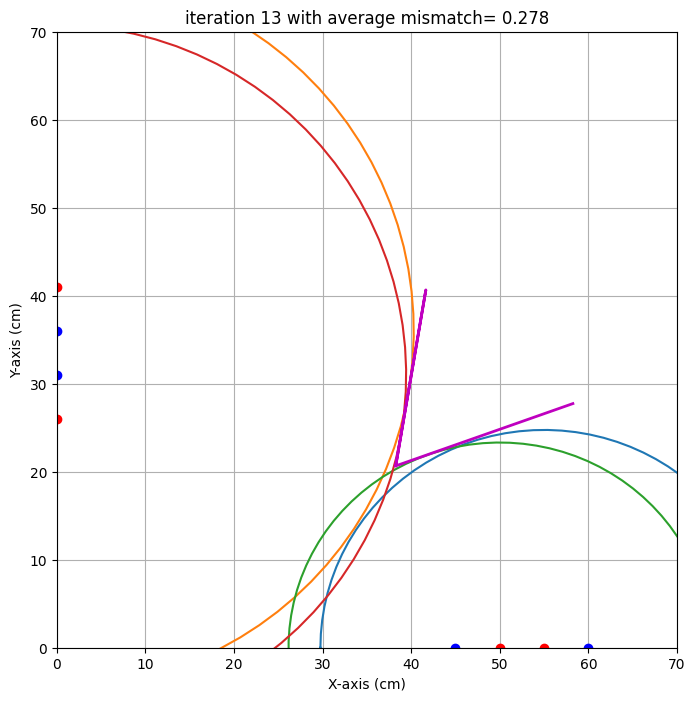

end iteration 13 with average mismatch= 0.278
end iteration 14 with average mismatch= 0.277
end iteration 15 with average mismatch= 0.277
end iteration 16 with average mismatch= 0.277
end iteration 17 with average mismatch= 0.277
end iteration 18 with average mismatch= 0.277
end iteration 19 with average mismatch= 0.269


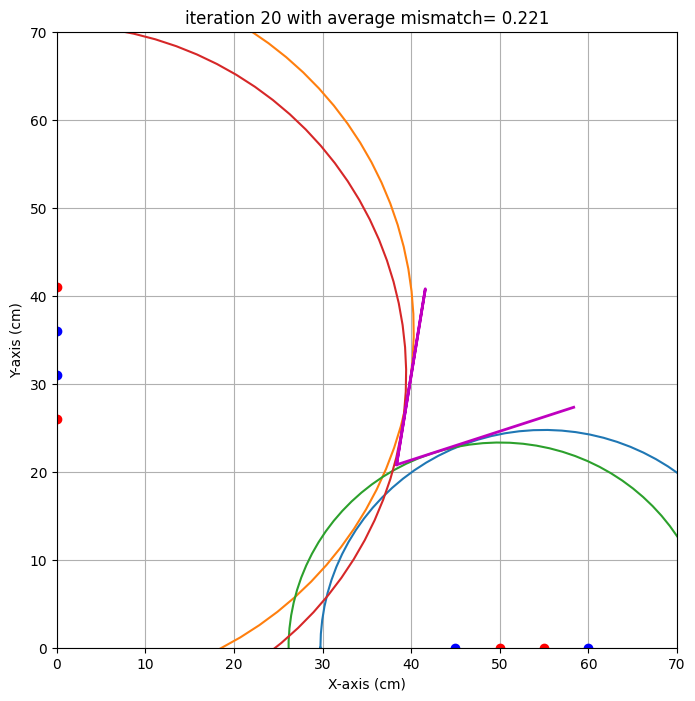

end iteration 20 with average mismatch= 0.221
end iteration 21 with average mismatch= 0.220
end iteration 22 with average mismatch= 0.219
end iteration 23 with average mismatch= 0.219
end iteration 24 with average mismatch= 0.219


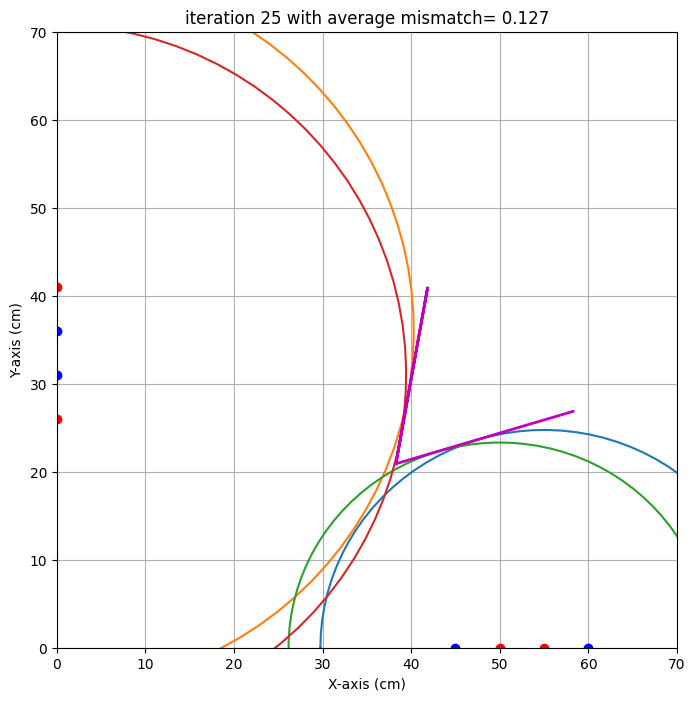

end iteration 25 with average mismatch= 0.127


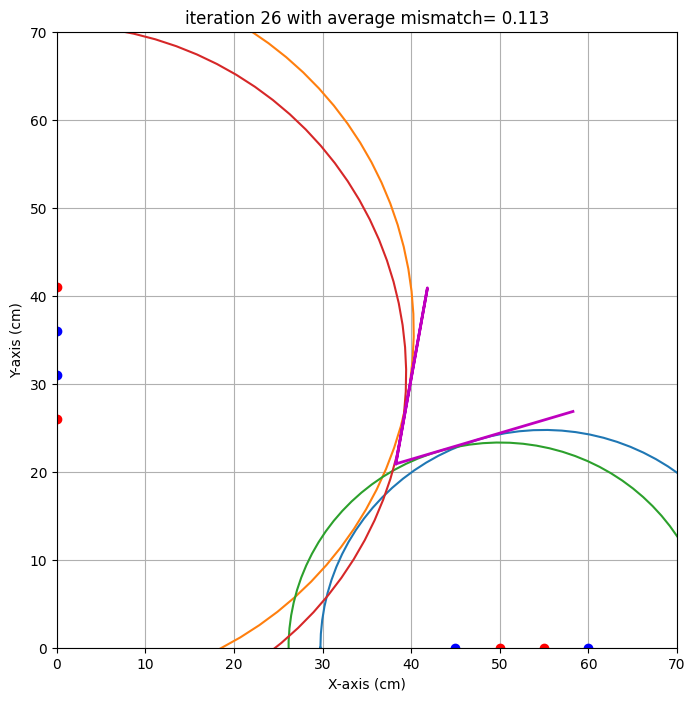

end iteration 26 with average mismatch= 0.113
end iteration 27 with average mismatch= 0.111
end iteration 28 with average mismatch= 0.110
end iteration 29 with average mismatch= 0.110
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.110
###############################################################################
end of iteration  30
Best alpha=  16.57 with uncertainty=   0.80
Best beta =  10.13 with uncertainty=   2.98
Best x0   =  38.26 with uncertainty=   0.54
Best y0   =  20.89 with uncertainty=   0.26
###############################################################################


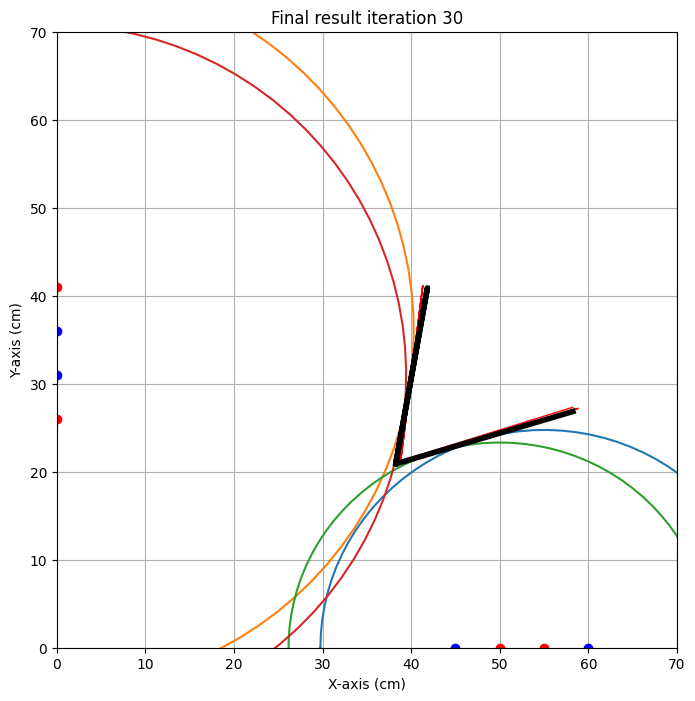

{'alpha': np.float64(16.573980179625718), 'alpha_eps': np.float64(0.802422679832631), 'beta': np.float64(10.131507307519126), 'beta_eps': np.float64(2.9839520570865528), 'x0': np.float64(38.25646089693141), 'x0_eps': np.float64(0.5435507128780515), 'y0': np.float64(20.88937670362484), 'y0_eps': np.float64(0.2575279179313412)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  73.0
1   0  43   0  53  73.7
2  55   0  45   0  71.5
3   0  48   0  38  72.0


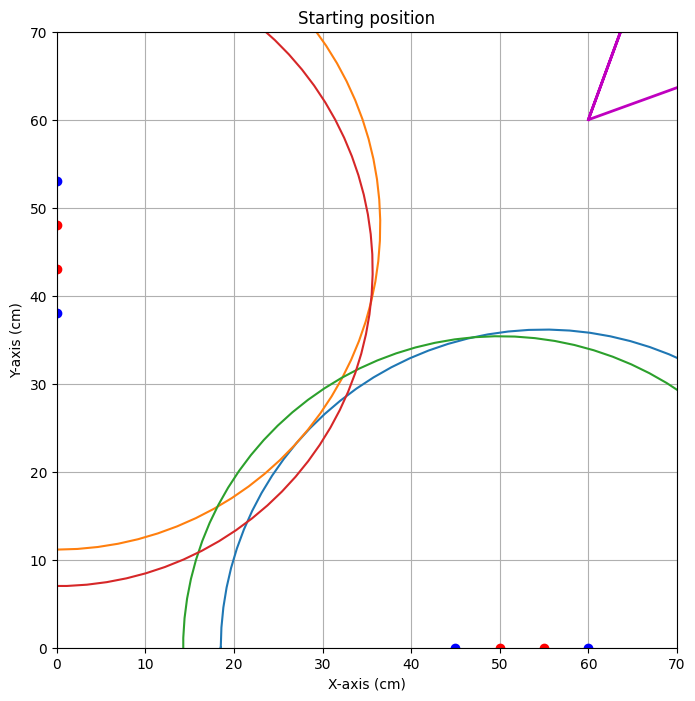


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=56.571


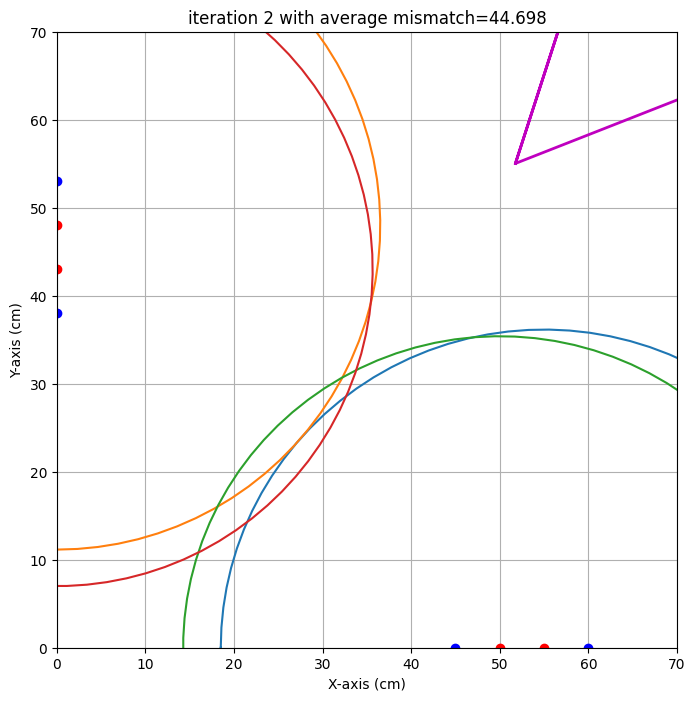

end iteration 2 with average mismatch=44.698


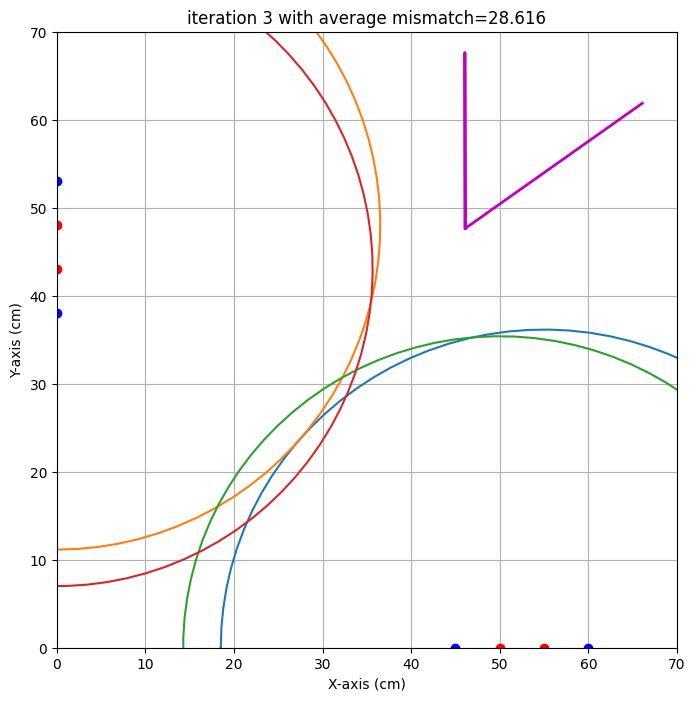

end iteration 3 with average mismatch=28.616


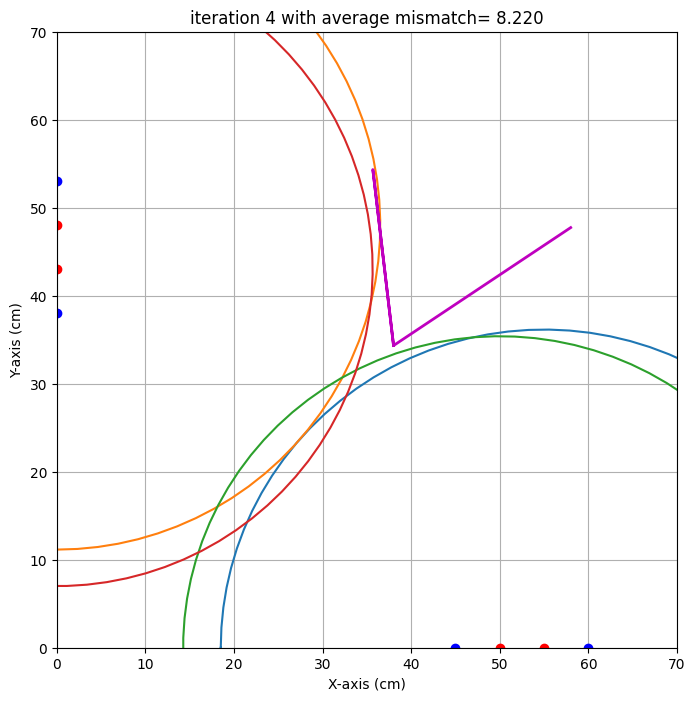

end iteration 4 with average mismatch= 8.220


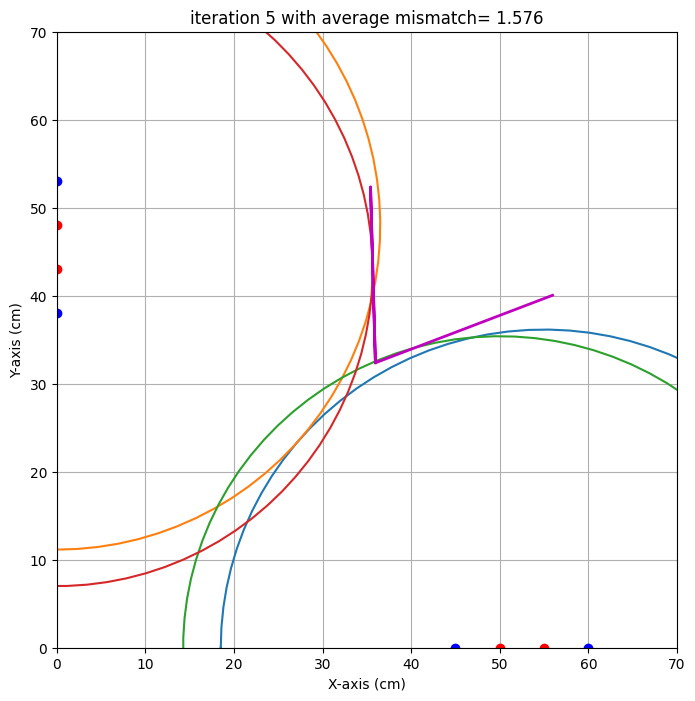

end iteration 5 with average mismatch= 1.576


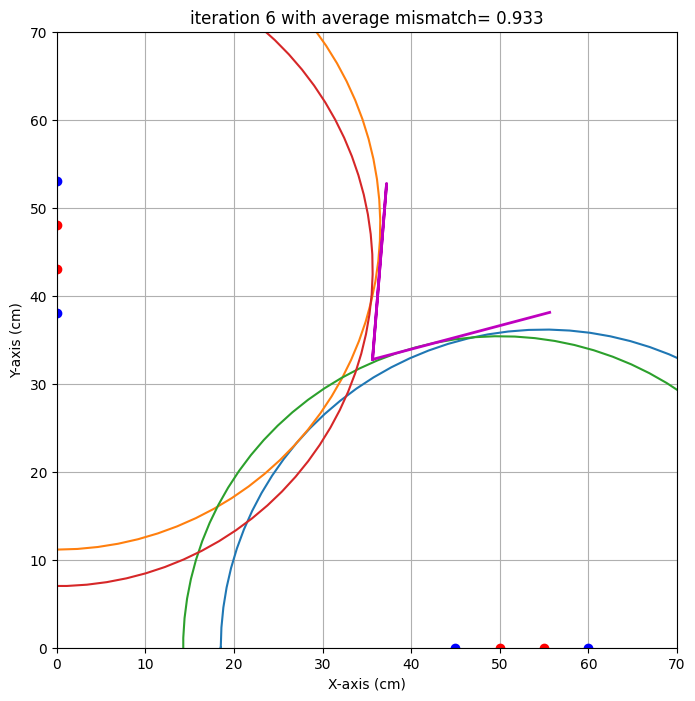

end iteration 6 with average mismatch= 0.933


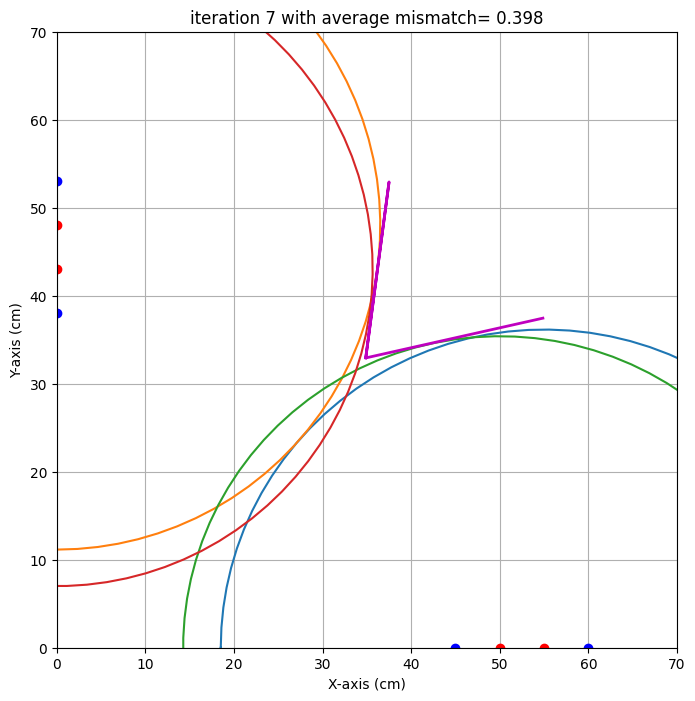

end iteration 7 with average mismatch= 0.398
end iteration 8 with average mismatch= 0.395
end iteration 9 with average mismatch= 0.387


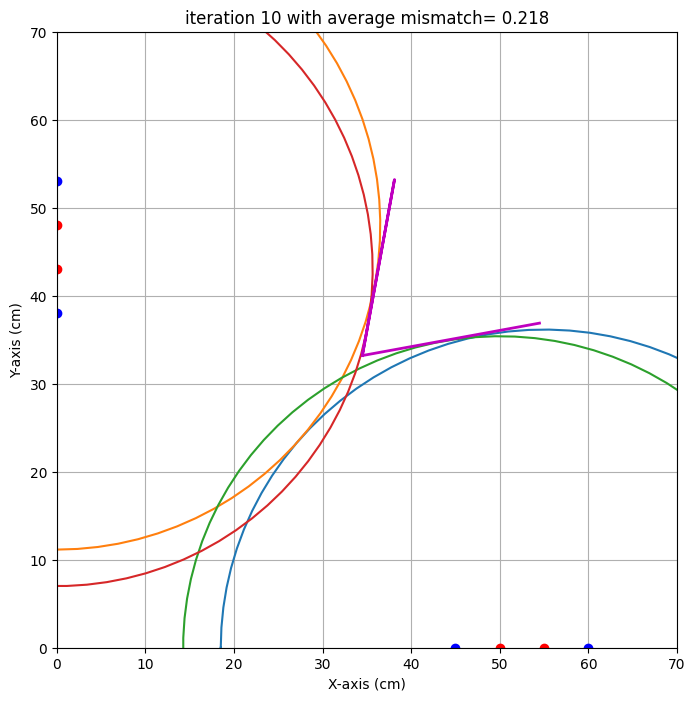

end iteration 10 with average mismatch= 0.218
end iteration 11 with average mismatch= 0.200
end iteration 12 with average mismatch= 0.190
end iteration 13 with average mismatch= 0.180
end iteration 14 with average mismatch= 0.180
end iteration 15 with average mismatch= 0.180
end iteration 16 with average mismatch= 0.180
end iteration 17 with average mismatch= 0.180
end iteration 18 with average mismatch= 0.180
end iteration 19 with average mismatch= 0.180
end iteration 20 with average mismatch= 0.180
end iteration 21 with average mismatch= 0.180
end iteration 22 with average mismatch= 0.180
end iteration 23 with average mismatch= 0.167


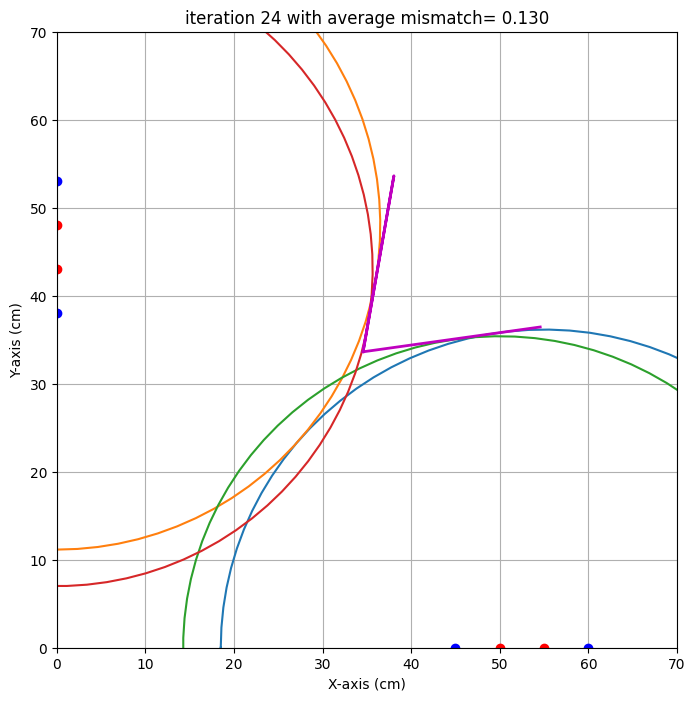

end iteration 24 with average mismatch= 0.130
end iteration 25 with average mismatch= 0.130
end iteration 26 with average mismatch= 0.130
end iteration 27 with average mismatch= 0.130
end iteration 28 with average mismatch= 0.130
end iteration 29 with average mismatch= 0.130
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.130
###############################################################################
end of iteration  30
Best alpha=   8.02 with uncertainty=   1.78
Best beta =   9.88 with uncertainty=   1.31
Best x0   =  34.57 with uncertainty=   0.23
Best y0   =  33.63 with uncertainty=   0.71
###############################################################################


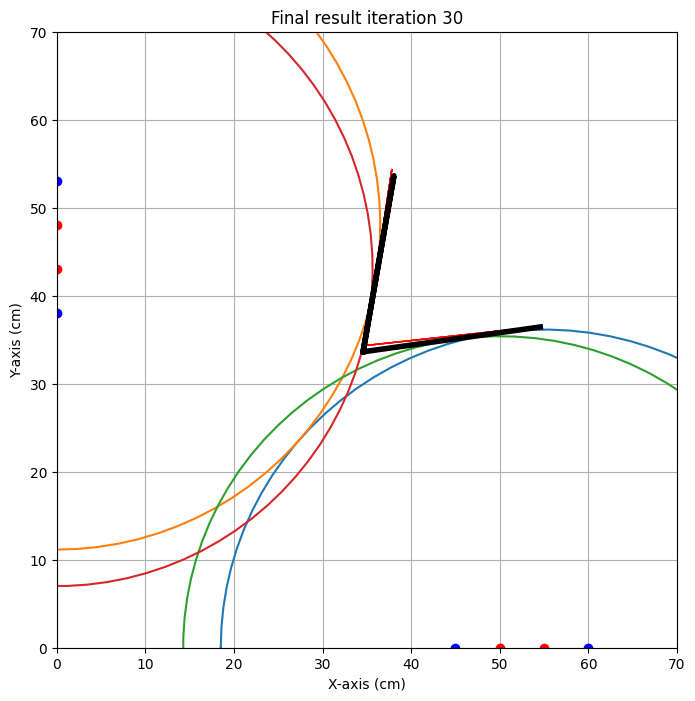

{'alpha': np.float64(8.020613875093025), 'alpha_eps': np.float64(1.7835065813487523), 'beta': np.float64(9.88427929254977), 'beta_eps': np.float64(1.30801650156989), 'x0': np.float64(34.565383058695346), 'x0_eps': np.float64(0.23105668241857558), 'y0': np.float64(33.62792645801382), 'y0_eps': np.float64(0.7108547560012255)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 38.3 cm met een standaardafwijking van 0.5 cm 
y0 target is : 21.5. Gevonden waarde: 20.9 cm met een standaardafwijking van 0.3 cm 
alpha target is : 15.0. Gevonden waarde: 16.6 graden met een standaardafwijking van 0.8 graad 
beta target is : 10.0. Gevonden waarde: 10.1 graden met een standaardafwijking van 3.0 graad 

locatie 2 
x0 target is : 34.0. Gevonden waarde: 34.6 cm met een standaardafwijking van 0.2 cm 
y0 target is : 33.0. Gevonden waarde: 33.6 cm met een standaardafwijking van 0.7 cm 
alpha target is : 13.0. Gevonden waarde: 8.0 graden met een standaardafwijking van 1.8 graad 
beta target is : 12.0. Gevon

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':38,#zelf aanvullen,
                    'y0':21.5,  #zelf aanvullen,
                    'alpha' : 15, #zelf aanvullen,
                    'beta' : 10},  #zelf aanvullen
           'locatie 2':{'x0':34,#zelf aanvullen,
                    'y0':33,  #zelf aanvullen,
                    'alpha' : 13, #zelf aanvullen,
                    'beta' : 12}  #zelf aanvullen
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        # [30,0,40,0, ongeldig]  
    [50,0,60,0,50.5],
    [0,41,0,31,81.2],
    [55,0,45,0,47.7],
    [0,26,0,36,79.5]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            # [30,0,40,0, ongeldig]  
    [50,0,60,0,73],
    [0,43,0,53,73.7],
    [55,0,45,0,71.5],
    [0,48,0,38,72]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

Test 1, niet gehaald:

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  70.0
1   0  41   0  51  80.9
2  55   0  45   0  71.7
3   0  46   0  56  78.8


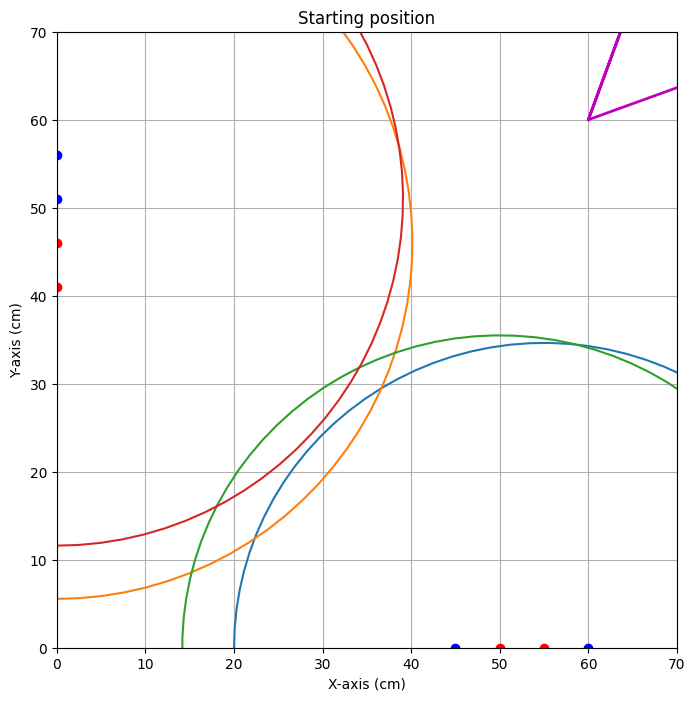


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.942


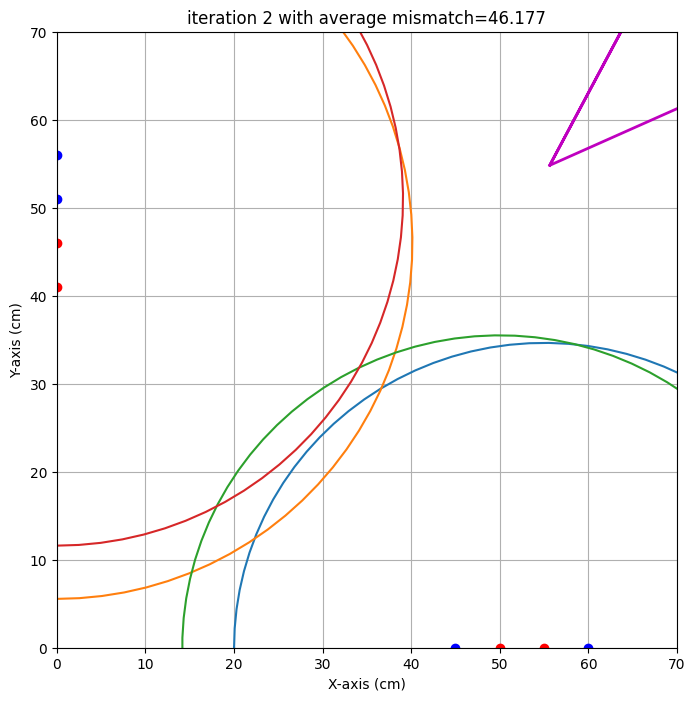

end iteration 2 with average mismatch=46.177


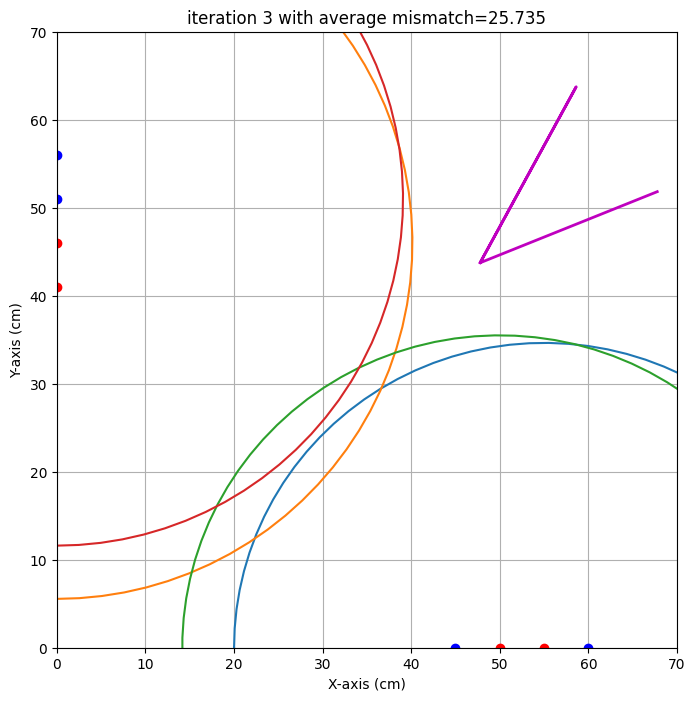

end iteration 3 with average mismatch=25.735


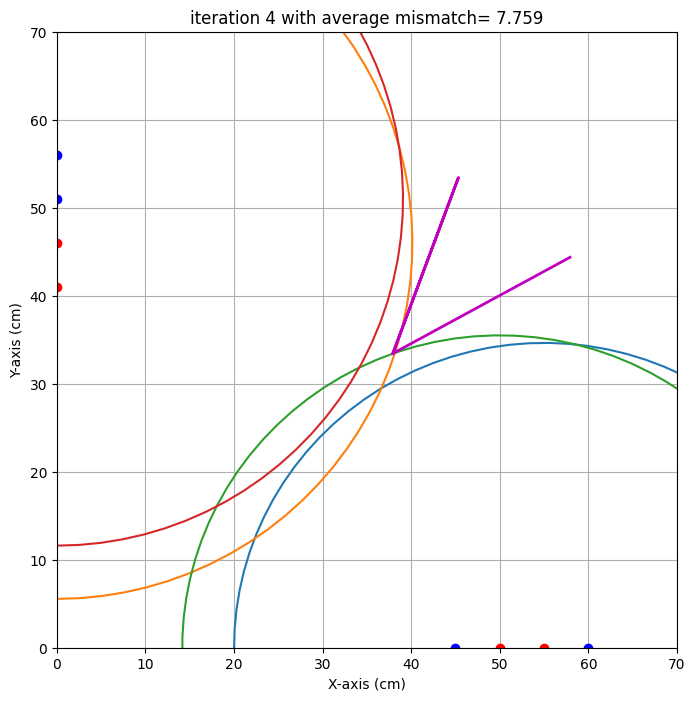

end iteration 4 with average mismatch= 7.759


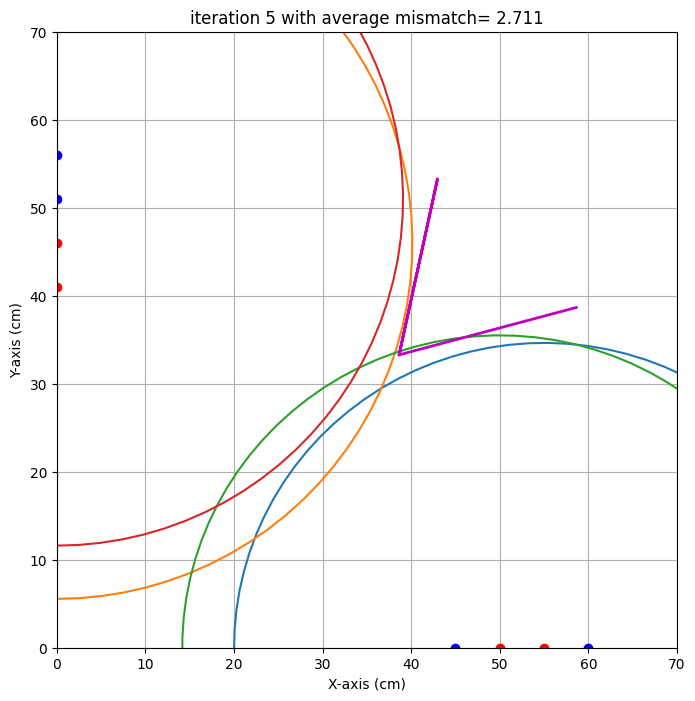

end iteration 5 with average mismatch= 2.711


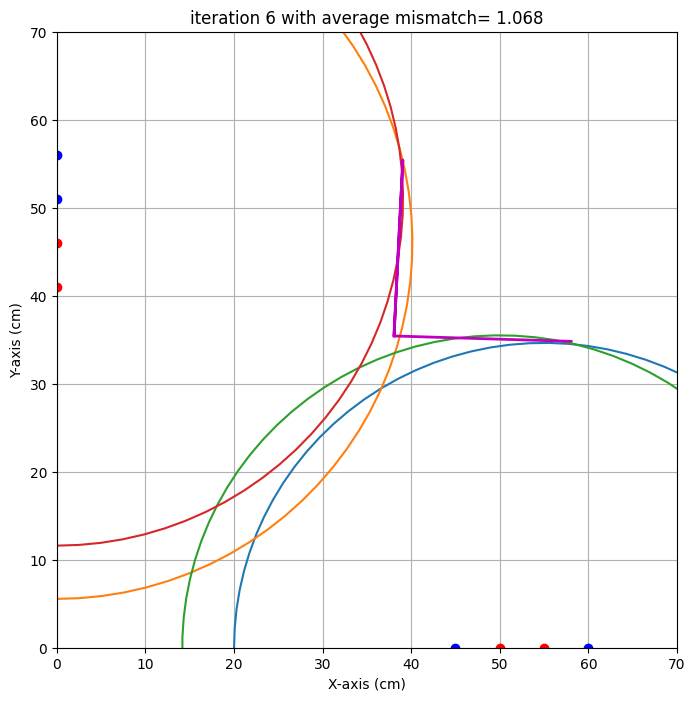

end iteration 6 with average mismatch= 1.068
end iteration 7 with average mismatch= 1.004


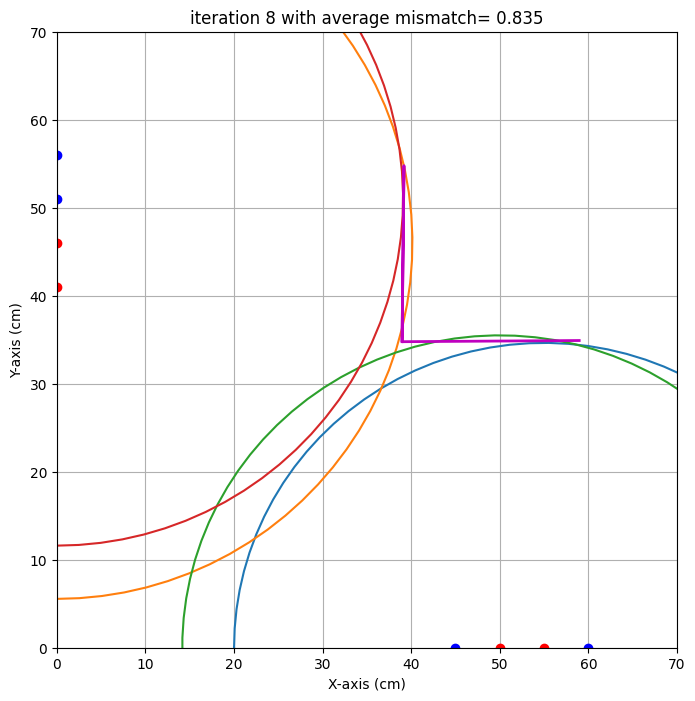

end iteration 8 with average mismatch= 0.835
end iteration 9 with average mismatch= 0.782
end iteration 10 with average mismatch= 0.782
end iteration 11 with average mismatch= 0.782
end iteration 12 with average mismatch= 0.746
end iteration 13 with average mismatch= 0.733
end iteration 14 with average mismatch= 0.728


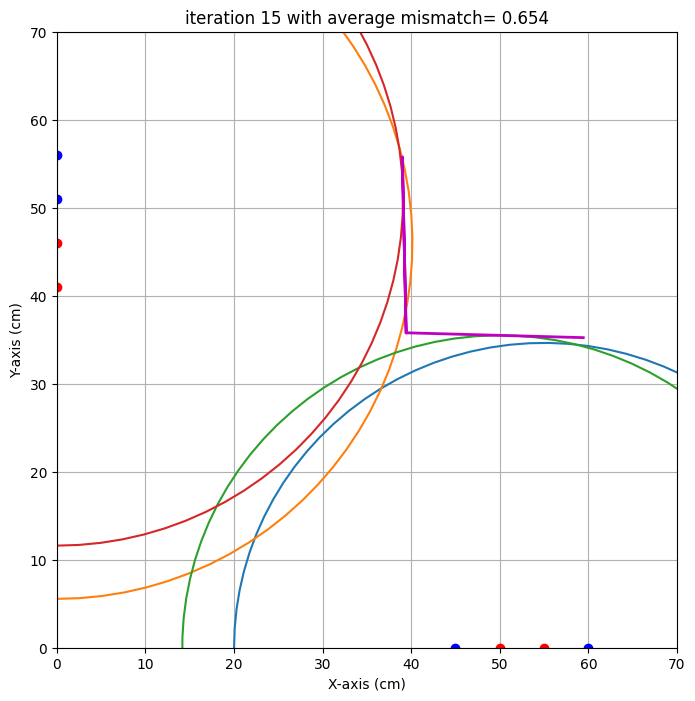

end iteration 15 with average mismatch= 0.654
end iteration 16 with average mismatch= 0.631
end iteration 17 with average mismatch= 0.617
end iteration 18 with average mismatch= 0.616
end iteration 19 with average mismatch= 0.616
end iteration 20 with average mismatch= 0.616
end iteration 21 with average mismatch= 0.616
end iteration 22 with average mismatch= 0.616
end iteration 23 with average mismatch= 0.616
end iteration 24 with average mismatch= 0.616
end iteration 25 with average mismatch= 0.616
end iteration 26 with average mismatch= 0.616
end iteration 27 with average mismatch= 0.616
end iteration 28 with average mismatch= 0.602
end iteration 29 with average mismatch= 0.594
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.594
###############################################################################
end of iteration  30
Best alpha=  -5.04 with uncertainty=   7.90
Best beta 

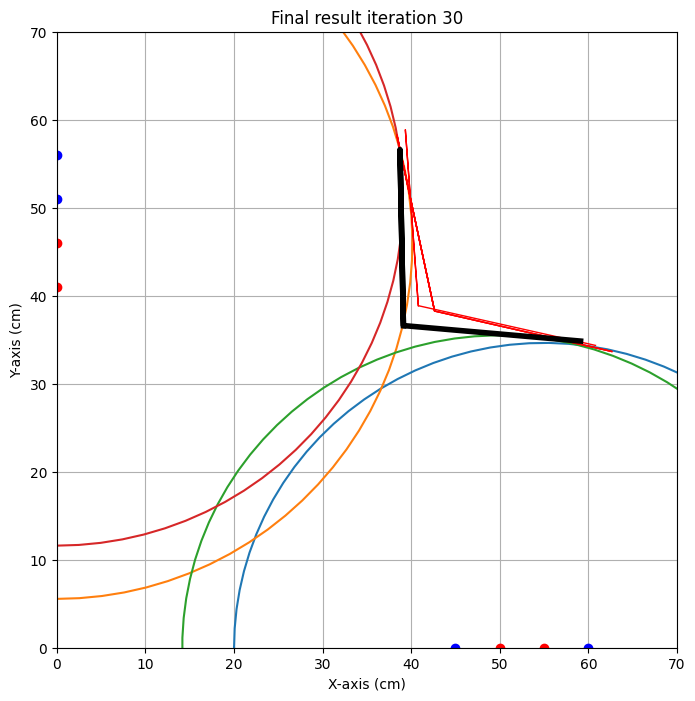

{'alpha': np.float64(-5.035277894562741), 'alpha_eps': np.float64(7.896100079857943), 'beta': np.float64(-1.1116894972553317), 'beta_eps': np.float64(10.897972583766725), 'x0': np.float64(39.122824042436136), 'x0_eps': np.float64(3.5212574913838495), 'y0': np.float64(36.607914059602976), 'y0_eps': np.float64(2.2594581648464995)}
test locatie 
x0 target is : 41.7. Gevonden waarde: 39.1 cm met een standaardafwijking van 3.5 cm 
y0 target is : 38.5. Gevonden waarde: 36.6 cm met een standaardafwijking van 2.3 cm 
alpha target is : -12.0. Gevonden waarde: -5.0 graden met een standaardafwijking van 7.9 graad 
beta target is : -10.0. Gevonden waarde: -1.1 graden met een standaardafwijking van 10.9 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':41.7,  # zelf aanvullen,
                    'y0':38.5,  # zelf aanvullen,
                    'alpha' : -12,  # zelf aanvullen,
                    'beta' : -10 # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [30,0,40,0, ongeldig]  
    [50,0,60,0,70],
    [0,41,0,51,80.9],
    [55,0,45,0,71.7],
    [0,46,0,56,78.8]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Test 2:

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  71.4
1   0  42   0  52  87.4
2  55   0  65   0  70.8
3  55   0  45   0  73.6
4   0  57   0  47  87.7
5   0  37   0  47  87.2


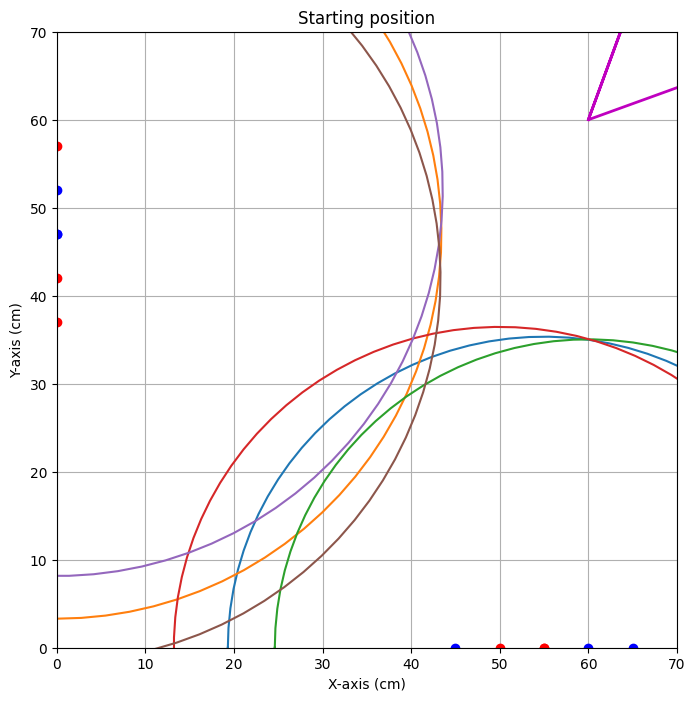


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.883


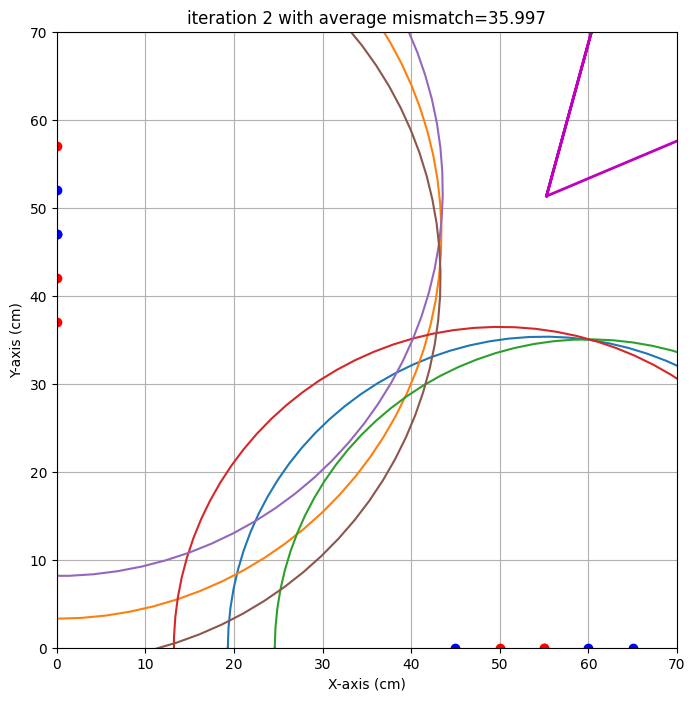

end iteration 2 with average mismatch=35.997


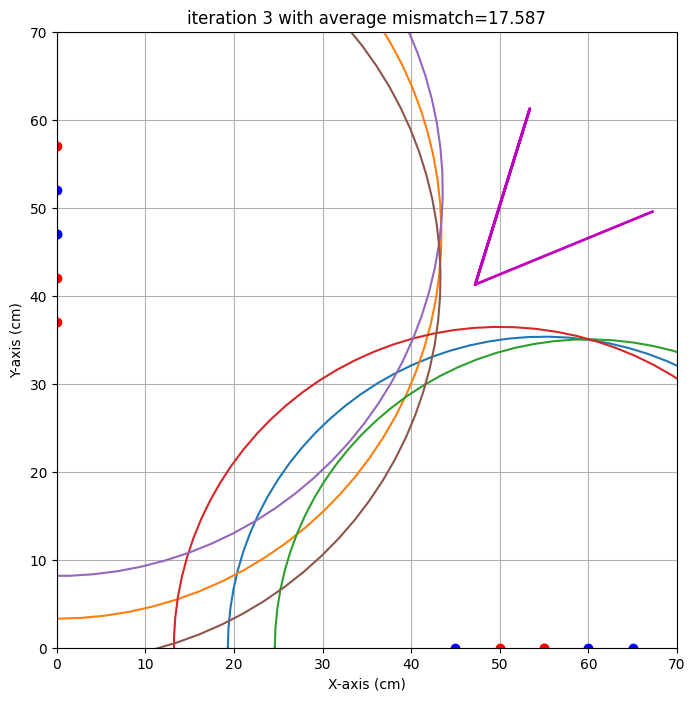

end iteration 3 with average mismatch=17.587


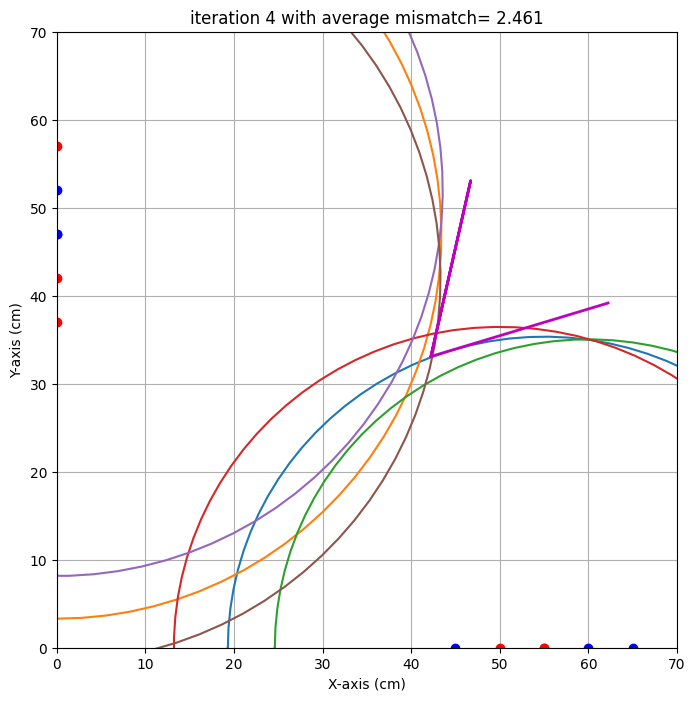

end iteration 4 with average mismatch= 2.461


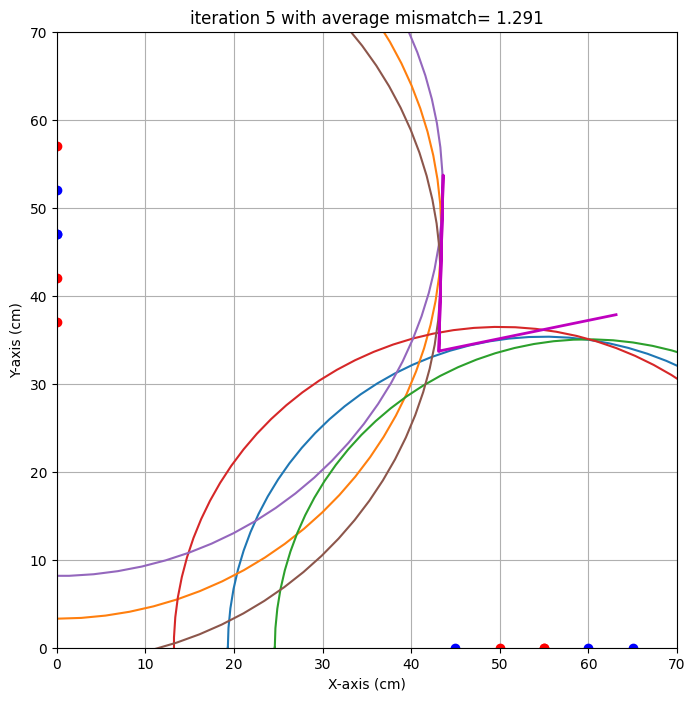

end iteration 5 with average mismatch= 1.291
end iteration 6 with average mismatch= 1.242
end iteration 7 with average mismatch= 1.239
end iteration 8 with average mismatch= 1.239
end iteration 9 with average mismatch= 1.239
end iteration 10 with average mismatch= 1.239
end iteration 11 with average mismatch= 1.239
end iteration 12 with average mismatch= 1.239
end iteration 13 with average mismatch= 1.239
end iteration 14 with average mismatch= 1.222
end iteration 15 with average mismatch= 1.213
end iteration 16 with average mismatch= 1.209
end iteration 17 with average mismatch= 1.209
end iteration 18 with average mismatch= 1.209
end iteration 19 with average mismatch= 1.190


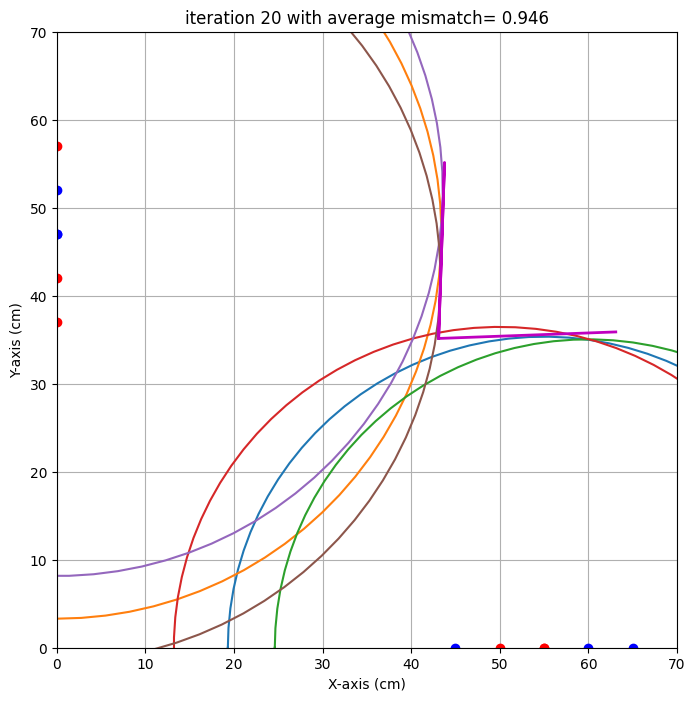

end iteration 20 with average mismatch= 0.946


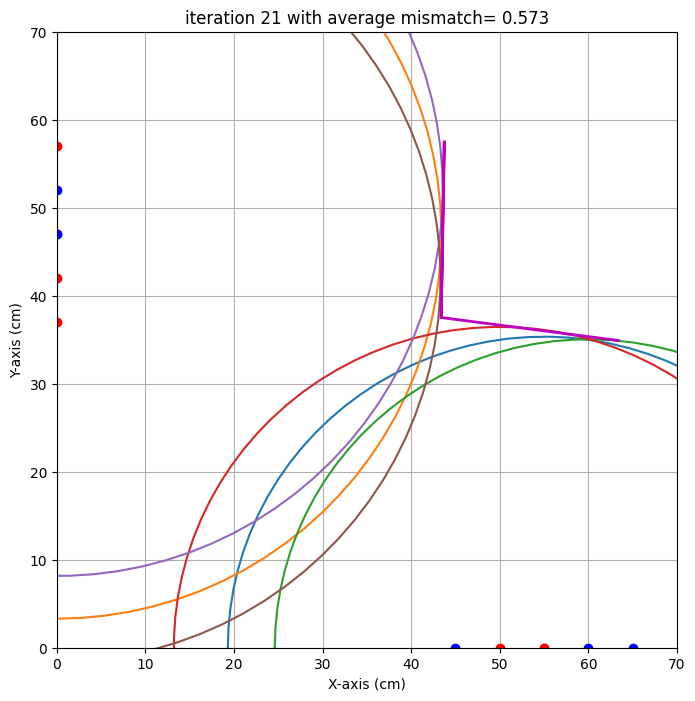

end iteration 21 with average mismatch= 0.573
end iteration 22 with average mismatch= 0.520
end iteration 23 with average mismatch= 0.515
end iteration 24 with average mismatch= 0.490
end iteration 25 with average mismatch= 0.469
end iteration 26 with average mismatch= 0.467
end iteration 27 with average mismatch= 0.466
end iteration 28 with average mismatch= 0.450
end iteration 29 with average mismatch= 0.450
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.450
###############################################################################
end of iteration  30
Best alpha=  -9.95 with uncertainty=   5.39
Best beta =   1.23 with uncertainty=   3.04
Best x0   =  43.27 with uncertainty=   0.69
Best y0   =  38.29 with uncertainty=   1.24
###############################################################################


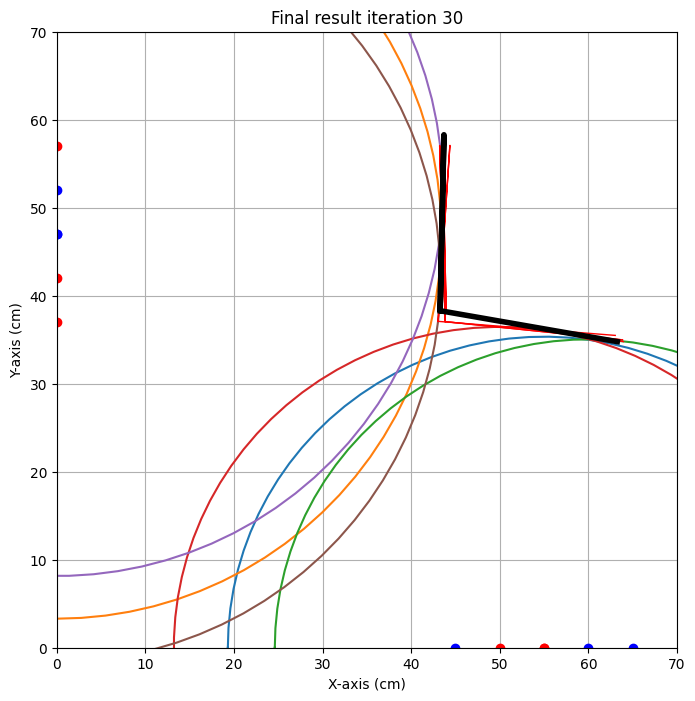

{'alpha': np.float64(-9.953371108262841), 'alpha_eps': np.float64(5.392244431138117), 'beta': np.float64(1.2259735166150223), 'beta_eps': np.float64(3.0436373363793066), 'x0': np.float64(43.26880104380708), 'x0_eps': np.float64(0.6928274221199899), 'y0': np.float64(38.29311462133219), 'y0_eps': np.float64(1.237599655457899)}
test locatie 
x0 target is : 43.7. Gevonden waarde: 43.3 cm met een standaardafwijking van 0.7 cm 
y0 target is : 37.2. Gevonden waarde: 38.3 cm met een standaardafwijking van 1.2 cm 
alpha target is : -9.0. Gevonden waarde: -10.0 graden met een standaardafwijking van 5.4 graad 
beta target is : 3.0. Gevonden waarde: 1.2 graden met een standaardafwijking van 3.0 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':43.7,  # zelf aanvullen,
                    'y0':37.2,  # zelf aanvullen,
                    'alpha' : -9,  # zelf aanvullen,
                    'beta' : 3 # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [30,0,40,0, ongeldig]  
    [50,0,60,0,71.4],
    [0,42,0,52,87.4],
    [55,0,65,0,70.8],
    [55,0,45,0,73.6],
    [0,57,0,47,87.7],
    [0,37,0,47,87.2]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Iteratie 0 & 1:
![Alt](foto_3.jpeg "Iteratie 0 & 1")

Bij iteratie 1 hebben we tov iteratie 0 de alleen de eerste stap aangepast. In plaats van stap voor stap (eerst rond x=25, dan rond x=35, etc.) opzoek te gaan naar het papiertje, beginnen we nu bij x=35 en springen we daarna (als x=35 een ongeldige meting is) gelijk naar x=55. Door de grootte van het papiertje weet je zeker dat hij bij ofwel x=35 ofwel x=55 staat. Dit bespaart een aantal metingen (=meer beter).


Iteratie 2:
![Alt](foto_5_iteratie_2.jpeg "Title")
Bij iteratie 2 hebben we tov iteratie 1 stappen 3 & 4 aangepast. We voegen twee extra metingen toe, zodat we een lagere standaardafwijking hebben bij het bepalen van de hoeken alfa en beta. De extra metingen voeren we uit op een afstand van vijf centimeter van de eerdere metingen. OP deze manier weten we nog zeker dat het een geldige meting zal opleveren. 
